# Final Team Project: Investment Research Agent - An Agentic AI Financial Analysis System

**Course:** AAI-520-02 Natural Language Processing and GenAI  
**Group Number:** 2  
**Team Members:** Robert Shifrin, Victoria Ritten, and Erika Gallegos  
**GitHub Repository:** `https://github.com/umea14/Investment-Research-Agent`

---
## Project Overview

This notebook builds an **Investment Research Agent**, a small team of
cooperating LLM agents that researches a stock end to end. Given a ticker and a question, the system plans the research, selects and runs data tools, summarizes recent news, reviews and improves its own drafts, remembers what it learned for future runs, and produces a sourced report with charts. The system uses free OpenRouter models and Yahoo Finance data.

**How to Run:** Run the cells from top to bottom and paste your OpenRouter key when prompted (it is never stored in the notebook). Free models are rate limited, and one end-to-end run makes roughly 15-25 LLM requests, so check your OpenRouter limits. If a cell reports "all 3 free attempts failed", wait a
minute and re-run that cell.

### Requirement Map

| Requirement | Where it is Implemented |
| --- | --- |
| Plans research steps for a stock | Section 4, `Coordinator.plan_research` |
| Uses tools dynamically | Sections 3-5: the LLM selects Yahoo Finance tools as JSON, and code validates the selection *before* anything runs |
| Self-reflects on output quality | Section 7, delegated self-reflection through `EvaluatorAgent` |
| Agent-to-agent delegation | Sections 4, 6, 7, and 10: `send_to` logs show the Coordinator delegating to specialists and the Evaluator, with specialists returning results to the Coordinator |
| Learns across runs | Section 8, `LessonMemory` and `LearningCoordinator.reflect` |
| Workflow 1: prompt chaining | Section 5, `NewsResearcherAgent` |
| Workflow 2: routing | Section 6, `RoutingCoordinator.route_task` |
| Workflow 3: evaluator-optimizer | Section 7, `ReviewingCoordinator.refine_packet` |
| Evidence-based report and charts | Section 9 |
| End-to-end demonstration and tests | Section 10 |

### Agent Design and Workflows

The system has four agents that share one base class (`Agent`): a
**Coordinator** (plans, routes, merges, reviews and reports); a
**Researcher** (market data and numerical analysis); a **NewsResearcher**
(prompt chain over headlines); and an **Evaluator** (independent reviewer).
Agents talk through `send_to`, which logs every delegation, so each run has a
visible audit trail.

```
question + ticker
      |
  Coordinator --- plan (LLM) --- route (LLM; keyword rules if all models fail)
      |--> Researcher:     Yahoo prices + financials -> metrics (code) -> narrative (LLM)
      |--> NewsResearcher: ingest -> preprocess -> classify -> [gate] -> extract -> summarize
      |
  Evaluator <-- each draft: score -> feedback -> revise (at most 2 rounds)
      |
  LessonMemory <-- reflect on feedback; lessons are recalled next run
      |
  Coordinator --> executive summary + report + charts
```

**Design Principles used Throughout:** The LLM decides *what to do* (which tools, which specialist, and how to word the analysis); **code** computes the core financial metrics, validates structured LLM outputs where schemas are defined, screens generated percentages against supplied metrics, and bounds every loop. A failed or invalid LLM response is retried on at most three free models and is never replaced by an invented one.

### Agent Functions and Capabilities

* **Planning:** the Coordinator writes a 3-5 step plan that respects the question and any excluded tools.
* **Dynamic tool use:** The Researcher chooses `get_stock_prices` and/or
  `get_company_financials` (and the period) from the question; the news agent uses `get_company_news`. Selections that break a constraint are rejected.
* **Analysis:** Price change, drawdown, volatility, and quarter-over-quarter growth are computed in code rather than by the LLM. The LLM explains these metrics, while an automatic check screens percentages in the generated market analysis against the supplied computed values within a rounding tolerance.
* **Self-reflection (delegated):** The system reflects on draft quality through an independent Evaluator, which scores each draft for accuracy, completeness, and clarity against the evidence.
* **Learning:** Feedback is generalized into short rules, stored in a JSON file, and injected into the authors' prompts on later runs.

### Evaluation and Iteration

Each draft goes through a bounded evaluator-optimizer loop. The verdict is
computed in code from the scores (approve only when every score is at least 4). An automatic grounding check also caps the accuracy score
if a draft quotes a percentage that is not in the evidence. Revisions receive the reviewer's feedback and the previous draft. First-draft versus final-draft scores are charted in Section 9, and Section 10 compares runs to show whether recalled lessons change the first-draft quality.   

**RAG Design Choice:** RAG is intentionally not used in this implementation. The project works from live structured Yahoo Finance data and recent Yahoo Finance news, so direct tool retrieval, routing, prompt chaining, evaluation, and persistent memory are the more relevant agentic mechanisms for this scope.

**Note:** 429 or provider overload errors do not necessarily indicate a problem with the code. They may occur when a model reaches its usage limit or is temporarily unavailable. The code automatically tries fallback models. If all attempts fail, wait and retry the cell or select another available free model from OpenRouter.

---
# 1. Environment Setup and Dependencies

In [ ]:
!pip install -q openai yfinance jsonschema matplotlib

In [ ]:
# Core utilities for copying data, timestamps, file storage, and IDs
from copy import deepcopy
from datetime import datetime, timezone
from pathlib import Path
import json
import re
import time
import uuid
from getpass import getpass

# Data handling, schema validation, LLM access, and financial data
import pandas as pd
from jsonschema import Draft202012Validator, ValidationError
from openai import OpenAI, APIStatusError, APIConnectionError
import yfinance as yf


# Free OpenRouter models used for planning tasks, with fallback options
PLANNING_MODELS = (
    "nvidia/nemotron-3-super-120b-a12b:free",
    "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    "qwen/qwen3.8-27b:free",
)

# Free OpenRouter models used for research and analysis
RESEARCH_MODELS = (
    "nvidia/nemotron-3-super-120b-a12b:free",
    "qwen/qwen3.8-27b:free",
    "openrouter/free",
)

# Valid price history periods and financial tools available to the agents
PERIODS = ("1mo", "3mo", "6mo", "1y", "2y", "5y")
TOOL_NAMES = ("get_stock_prices", "get_company_financials")


# Return the current UTC timestamp for logs and stored results
def utc_now():
    return datetime.now(timezone.utc).isoformat()


# Validate and standardize stock ticker symbols
def normalize_ticker(ticker):
    if not isinstance(ticker, str) or not ticker.strip():
        raise ValueError("Provide a nonempty stock symbol.")
    return ticker.strip().upper()


# Create a structured research task from the user's inputs
def make_task(ticker, question, price_period=None, excluded_tools=()):
    """Optional structured constraints supplement, rather than replace, the
    question."""
    if not isinstance(question, str) or not question.strip():
        raise ValueError("Provide a nonempty research question.")
    if price_period is not None and price_period not in PERIODS:
        raise ValueError(f"price_period must be one of {PERIODS}.")
    if isinstance(excluded_tools, str) or set(excluded_tools) - set(
        TOOL_NAMES
    ):
        raise ValueError("excluded_tools must contain registered tool names.")
    return {
        "run_id": str(uuid.uuid4()),
        "ticker": normalize_ticker(ticker),
        "question": question.strip(),
        "price_period": price_period,
        "excluded_tools": list(excluded_tools),
    }


# Sanitize API errors before they are displayed or stored
def safe_error(error):
    """Keep provider errors useful without persisting credentials or long
    payloads."""
    return re.sub(r"sk-[A-Za-z0-9_-]+", "[REDACTED]", str(error))[:300]

In [ ]:
# Each teammate enters their own key
# Never put the key in the notebook source
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=getpass("Enter your OpenRouter API key: ").strip(),
    max_retries=0,
    timeout=60.0,
)
print("OpenRouter client configured.")

Enter your OpenRouter API key: ··········
OpenRouter client configured.


In [ ]:
from types import SimpleNamespace


class ThrottledClient:
    """Spaces requests out so free-tier per-minute limits are not hit."""

    def __init__(self, client, min_interval=3.5, _state=None):
        # Store the OpenAI/OpenRouter client and minimum delay between requests
        self._client, self.min_interval = client, min_interval

        # Share timing state across wrapped client instances
        self._state = _state if _state is not None else {"last": 0.0}

        # Preserve the usual client.chat.completions.create() interface
        self.chat = SimpleNamespace(
            completions=SimpleNamespace(create=self._create)
        )

    def with_options(self, **options):
        # Create another throttled client while keeping the same timing state
        return ThrottledClient(
            self._client.with_options(**options),
            self.min_interval,
            self._state,
        )

    def _create(self, **request):
        # Wait if needed before sending the next API request
        wait = self._state["last"] + self.min_interval - time.monotonic()
        if wait > 0:
            time.sleep(wait)

        self._state["last"] = time.monotonic()
        return self._client.chat.completions.create(**request)


# Wrap the existing client so all later LLM calls respect the rate limit
client = ThrottledClient(client)

print("Requests are now spaced to respect free-tier rate limits.")

Requests are now spaced to respect free-tier rate limits.


## 2. Base Agent

Following the lab 7, each agent has a name, role, model choices, session memory, process, and send_to. LLM requests have at most three free-model attempts. Invalid outputs are rejected; unsuccessful requests remain errors.

In [ ]:
class Agent:
    """Base class: identity, role, LLM calls, memory and send_to."""

    def __init__(
        self,
        name,
        role,
        client,
        models,
        event_log=None,
        verbose=True,
        retry_delay=2,
    ):
        # Limit each agent to one to three free OpenRouter models
        if (
            not models
            or len(models) > 3
            or any(
                m != "openrouter/free" and not m.endswith(":free")
                for m in models
            )
        ):
            raise ValueError("Configure one to three free model IDs only.")

        self.name, self.role = name, role
        self.client, self.models = client, tuple(dict.fromkeys(models))

        # Short-term session history for this agent
        self.memory = (
            []
        )  # Session history only: NOT learning across notebook restarts

        # Shared log records agent-to-agent delegation events
        self.event_log = event_log if event_log is not None else []
        self.verbose, self.retry_delay = verbose, retry_delay
        self.last_attempts = []

    def _log(self, message):
        if self.verbose:
            print(message)

    def call_llm(self, prompt, validator, response_format=None):
        """Bounded fallback, including invalid outputs; never fabricate a
        response."""

        # Track each model attempt for transparency and debugging
        self.last_attempts = []
        messages = [
            {"role": "system", "content": f"You are {self.name}. {self.role}"},
            {"role": "user", "content": prompt},
        ]

        # Try configured models in order until a valid response is returned
        for index, model in enumerate(self.models):
            if index and self.retry_delay:
                time.sleep(self.retry_delay)

            self._log(
                f"{self.name}: attempt {index + 1}/{len(self.models)} —"
                f" {model}"
            )

            attempt = {"requested_model": model, "status": "failed"}
            self.last_attempts.append(attempt)

            request = dict(
                model=model,
                messages=messages,
                max_tokens=4096,
                temperature=1.0,
            )

            # Request structured output when a schema is provided
            if response_format:
                request.update(
                    response_format=response_format,
                    extra_body={"provider": {"require_parameters": True}},
                )

            try:
                response = self.client.with_options(
                    max_retries=0
                ).chat.completions.create(**request)

            except APIStatusError as error:
                attempt["error"] = (
                    f"HTTP {error.status_code}: "
                    f"{safe_error(getattr(error, 'message', ''))[:150]}"
                )

                # Invalid credentials, billing, and malformed requests
                # require a user or code fix
                if error.status_code not in {
                    404,
                    408,
                    429,
                    500,
                    502,
                    503,
                    504,
                }:
                    raise
                reason = attempt["error"]

            except APIConnectionError:
                reason = "Connection failed or timed out"

            else:
                attempt["actual_model"] = getattr(response, "model", None)
                provider_error = getattr(response, "error", None)

                if provider_error:
                    reason = safe_error(
                        provider_error.get("message", "Provider error")
                    )
                    if str(provider_error.get("code")) in {
                        "400",
                        "401",
                        "402",
                        "403",
                        "413",
                        "422",
                    }:
                        attempt["error"] = reason
                        raise RuntimeError(reason)

                elif not getattr(response, "choices", None):
                    reason = "No choices returned"

                else:
                    choice = response.choices[0]
                    content = choice.message.content

                    if choice.finish_reason == "content_filter":
                        attempt["error"] = "Provider filtered the response"
                        raise RuntimeError(attempt["error"])

                    if choice.finish_reason != "stop":
                        reason = f"Incomplete response: {choice.finish_reason}"

                    elif not isinstance(content, str) or not content.strip():
                        reason = "Empty response"

                    else:
                        # Validate the LLM output before accepting it
                        try:
                            value = validator(content)
                        except (ValueError, ValidationError) as error:
                            reason = "Rejected output: " + safe_error(error)
                        else:
                            attempt["status"] = "success"
                            self._log(
                                f"{self.name}: accepted response from"
                                f" {response.model}"
                            )
                            return (
                                value,
                                response.model,
                                deepcopy(self.last_attempts),
                            )

            attempt["error"] = reason
            self._log(f"{self.name}: {reason}")

            # Corrective feedback accompanies the next bounded fallback attempt
            messages.append({
                "role": "user",
                "content": (
                    "Previous attempt failed validation or availability."
                    " Return a complete answer to the original task. Detail:"
                    f" {reason}"
                ),
            })

        # Fail explicitly rather than inventing a result
        raise RuntimeError(
            f"{self.name}: all {len(self.models)} free attempts failed. "
            "No successful result was fabricated. Try later."
        )

    def process(self, task):
        # Each specialized agent defines its own task processing behavior
        raise NotImplementedError(
            "Each specialist implements its own process method."
        )

    def remember(self, task, result):
        # Store a brief record of this task in the agent's session memory
        self.memory.append({
            "run_id": task["run_id"],
            "task": task["question"],
            "result_status": result["status"],
            "recorded_at": utc_now(),
        })

    def send_to(self, other_agent, task):
        # Delegate a task to another agent and record the handoff
        event = {
            "run_id": task["run_id"],
            "from": self.name,
            "to": other_agent.name,
            "task": task["question"],
            "status": "started",
            "started_at": utc_now(),
        }

        self.event_log.append(event)
        self._log(f"{self.name} → {other_agent.name}: {task['question']}")

        try:
            # The receiving agent independently processes the delegated task
            result = other_agent.process(deepcopy(task))
        except Exception as error:
            event.update(
                status="failed", error=safe_error(error), finished_at=utc_now()
            )
            raise

        # Record the completed delegation in the shared event log
        event.update(
            status=result.get("status", "completed"), finished_at=utc_now()
        )

        return result

---
# 3. Financial Data Retrieval and Tools

Two tools retrieve adjusted daily prices and up to four quarterly income statements. Each result includes its source, retrieval time and status. Four quarters support quarter-over-quarter comparisons; earnings-announcement dates are not retrieved.

In [ ]:
class YahooFinanceTools:
    """Yahoo Finance retrieval tools shared by the research agent."""

    def __init__(self, ticker_factory=None, retry_delay=2):
        self.ticker_factory = ticker_factory or yf.Ticker
        self.retry_delay = retry_delay

        # Registry of financial tools available to the research agent
        self.functions = {
            "get_stock_prices": self.get_stock_prices,
            "get_company_financials": self.get_company_financials,
        }

    def _result(self, ticker, period):
        # Standard result structure returned by each Yahoo Finance tool
        return {
            "ticker": normalize_ticker(ticker),
            "period": period,
            "source": "Yahoo Finance via yfinance",
            "retrieved_at": utc_now(),
            "status": "error",
            "data": [],
        }

    def get_stock_prices(self, ticker, period="1mo"):
        """Daily adjusted OHLC, volume and corporate-action columns if
        available."""
        result = self._result(ticker, period)

        try:
            if period not in PERIODS:
                raise ValueError("Unsupported price-history period.")

            # Retry briefly because Yahoo may occasionally return an empty frame
            for attempt in range(3):
                frame = self.ticker_factory(result["ticker"]).history(
                    period=period,
                    interval="1d",
                    auto_adjust=True,
                    actions=True,
                )
                if not frame.empty:
                    break
                if attempt < 2:
                    time.sleep(self.retry_delay * (attempt + 1))

            # Require usable closing price data before accepting the response
            if (
                frame.empty
                or "Close" not in frame
                or frame["Close"].notna().sum() == 0
            ):
                raise ValueError("No usable closing-price data returned.")

            # Clean the data and convert it to JSON friendly records
            frame = frame.sort_index().copy()
            frame.index.name = "Date"
            frame = frame.reset_index()
            frame["Date"] = frame["Date"].astype(str)

            result.update(
                status="success",
                adjustment="auto_adjust=True",
                row_count=len(frame),
                data=json.loads(
                    frame.to_json(orient="records", date_format="iso")
                ),
            )

        except Exception as error:
            result["error"] = safe_error(error)

        return result

    def get_company_financials(self, ticker):
        """Up to four reported quarters, newest first; values retain Yahoo
        units."""
        result = self._result(ticker, "Up to four reported quarters")

        try:
            # Retrieve the most recent quarterly income statements
            frame = self.ticker_factory(result["ticker"]).quarterly_income_stmt

            if frame.empty:
                raise ValueError("No quarterly income statements returned.")

            # Reformat so each row represents one quarter
            frame = frame.T.sort_index(ascending=False).head(4).copy()

            # Confirm that at least one key financial measure is available
            if not any(
                c in frame and frame[c].notna().any()
                for c in ("Total Revenue", "Net Income")
            ):
                raise ValueError(
                    "Revenue and net income are missing from these statements."
                )

            frame.index.name = "quarter_end"
            frame = frame.reset_index()
            frame["quarter_end"] = frame["quarter_end"].astype(str)

            result.update(
                status="success",
                row_count=len(frame),
                units=(
                    "Original reporting units; currency not independently"
                    " verified"
                ),
                data=json.loads(
                    frame.to_json(orient="records", date_format="iso")
                ),
            )

        except Exception as error:
            result["error"] = safe_error(error)

        return result


# Plain language descriptions used when the agent chooses which tool to call
TOOL_DESCRIPTIONS = {
    "get_stock_prices": (
        "Adjusted daily prices, volume, and available dividends/splits."
    ),
    "get_company_financials": (
        "Up to four reported quarterly income statements."
    ),
}


# JSON schema constrains the LLM to valid tool names and arguments
CALL_SCHEMA = {
    "type": "object",
    "properties": {
        "calls": {
            "type": "array",
            "minItems": 1,
            "maxItems": 2,
            "items": {
                "anyOf": [
                    {
                        "type": "object",
                        "properties": {
                            "name": {
                                "type": "string",
                                "enum": ["get_stock_prices"],
                            },
                            "arguments": {
                                "type": "object",
                                "properties": {
                                    "ticker": {
                                        "type": "string",
                                        "minLength": 1,
                                    },
                                    "period": {
                                        "type": "string",
                                        "enum": list(PERIODS),
                                    },
                                },
                                "required": ["ticker", "period"],
                                "additionalProperties": False,
                            },
                        },
                        "required": ["name", "arguments"],
                        "additionalProperties": False,
                    },
                    {
                        "type": "object",
                        "properties": {
                            "name": {
                                "type": "string",
                                "enum": ["get_company_financials"],
                            },
                            "arguments": {
                                "type": "object",
                                "properties": {
                                    "ticker": {
                                        "type": "string",
                                        "minLength": 1,
                                    }
                                },
                                "required": ["ticker"],
                                "additionalProperties": False,
                            },
                        },
                        "required": ["name", "arguments"],
                        "additionalProperties": False,
                    },
                ]
            },
        },
    },
    "required": ["calls"],
    "additionalProperties": False,
}

# Validator checks the LLM's requested tool calls before they are executed
CALL_VALIDATOR = Draft202012Validator(CALL_SCHEMA)

---
# 4. Research Planning and Dynamic Tool Use

The `Coordinator` creates a research plan and **delegates** the evidence-collection
task to `ResearcherAgent`. This is agent-to-agent communication, not a single agent calling a search tool: the Coordinator calls `send_to(Researcher, plan)`, the Researcher independently selects and executes the relevant tools, and the Researcher then calls `send_to(Coordinator, evidence)` to return the result. Every handoff is recorded in the shared delegation log.

`ResearcherAgent` chooses `get_stock_prices` and/or `get_company_financials` dynamically from the question. Tool selections are returned as validated JSON, checked against ticker/period/exclusion constraints **before** any tool executes, and then run only if valid. The demonstrations below make the plan, tool choices, and bidirectional delegation visible in the notebook output.

In [ ]:
# Researcher (Yahoo data retrieval) Agent
class ResearcherAgent(Agent):

    def __init__(self, client, tools, **kwargs):
        # Define the Researcher's role and rules for selecting financial tools
        role = (
            "You are the financial evidence collection agent. Select relevant"
            " tools using the original question, assisted by the plan. The"
            " original question and explicit constraints take priority. Never"
            " retrieve explicitly excluded information. For prices/volume"
            " select get_stock_prices; for quarterly revenue/profit select"
            " get_company_financials. Prices-only requests require only"
            " get_stock_prices. Match the ticker and requested period. Select"
            " all needed retrieval tools, at most once each. Return only the"
            " requested JSON; do not invent financial results. Tools: "
            + json.dumps(TOOL_DESCRIPTIONS)
        )
        super().__init__("Researcher", role, client, RESEARCH_MODELS, **kwargs)
        self.tools = tools

    def validate_selection(self, text, task):
      # Parse and validate the LLM's proposed tool calls
      selection = json.loads(text)
      CALL_VALIDATOR.validate(selection)
      seen = set()

      # Validate the entire batch before any tool can run
      for call in selection["calls"]:
          name, args = call["name"], call["arguments"]

          # Prevent unavailable or explicitly excluded tools from running
          if (
              name not in self.tools.functions
              or name in task["excluded_tools"]
          ):
              raise ValueError(
                  f"Tool is unavailable or explicitly excluded: {name}"
              )

          # Each retrieval tool may be selected only once
          if name in seen:
              raise ValueError("Select each tool at most once.")
          seen.add(name)

          # Ensure the selected tool uses the requested ticker
          if normalize_ticker(args["ticker"]) != task["ticker"]:
              raise ValueError(
                  "Tool ticker differs from the requested ticker."
              )
          args["ticker"] = task["ticker"]

          # Preserve an explicitly requested price history period
          if (
              name == "get_stock_prices"
              and task["price_period"] is not None
              and args["period"] != task["price_period"]
          ):
              raise ValueError(
                  "The price period differs from the explicit request."
              )

      # Check that the selection includes tools clearly required by the question
      question = task["question"].lower()
      required_tools = set()

      price_terms = (
          "price",
          "stock",
          "perform",
          "volume",
          "return",
          "volatil",
      )
      financial_terms = (
          "revenue",
          "income",
          "profit",
          "financial",
          "quarter",
          "earnings",
      )

      if (
          any(term in question for term in price_terms)
          and "get_stock_prices" not in task["excluded_tools"]
      ):
          required_tools.add("get_stock_prices")

      if (
          any(term in question for term in financial_terms)
          and "get_company_financials" not in task["excluded_tools"]
      ):
          required_tools.add("get_company_financials")

      missing = required_tools - seen
      if missing:
          raise ValueError(
              "Missing required tool(s) for the question: "
              + ", ".join(sorted(missing))
          )

      return selection

    def process(self, task):
        # Ask the LLM to dynamically select the appropriate retrieval tools
        selection, model, attempts = self.call_llm(
            json.dumps(task),
            lambda text: self.validate_selection(text, task),
            response_format={
                "type": "json_schema",
                "json_schema": {
                    "name": "research_tool_selection",
                    "strict": True,
                    "schema": CALL_SCHEMA,
                },
            },
        )

        # Execute the validated tool calls
        results = []
        for call in selection["calls"]:
            name, args = call["name"], call["arguments"]
            result = self.tools.functions[name](**args)

            results.append({
                "tool": name,
                "arguments": args,
                "result": result,
            })

            self._log(
                f"{self.name}: {name}({args}) → {result['status']}"
            )

        # Summarize the overall retrieval status
        success_count = sum(
            r["result"]["status"] == "success" for r in results
        )
        status = (
            "success"
            if success_count == len(results)
            else "partial" if success_count else "error"
        )

        # Package the retrieved evidence and execution details
        packet = {
            **task,
            "status": status,
            "tool_results": results,
            "execution_model": model,
            "execution_attempts": attempts,
            "selection_method": (
                "LLM-selected JSON, validated before execution"
            ),
        }

        self.remember(task, packet)
        return packet

In [ ]:
# Specialized Agents
class Coordinator(Agent):
    """Plans research, delegates retrieval, and receives the resulting
    evidence."""

    def __init__(self, client, **kwargs):
        # Define the Coordinator's planning role and research constraints
        role = (
            "You coordinate investment research and create its research plan."
            " Write a numbered plan with 3–5 short actionable steps in plain"
            " language. Do not output tool-call tags, JSON or executable"
            " calls. Respect the original question and explicit tool"
            " exclusions. Describe relevant tools and their inputs, without"
            " claiming they have run. Use only these retrieval tools: "
            + json.dumps(TOOL_DESCRIPTIONS)
            + ". Valid price periods: "
            + ", ".join(PERIODS)
            + ". Three months is a calendar period, not exactly 90 days;"
            " trading data omit weekends and exchange holidays. Do not"
            " expand a requested period to fill those gaps. Four quarters"
            " permit quarter-over-quarter comparisons, not year-over-year."
            " These tools do not retrieve earnings announcement dates, news,"
            " guidance, or analyst forecasts. Do not propose event reactions"
            " or invent unavailable facts. Mention relevant limitations."
            " Numerical analysis is delegated to later specialists."
        )
        super().__init__(
            "Coordinator", role, client, PLANNING_MODELS, **kwargs
        )

        # Registered specialist agents available for delegation
        self.team = {}
        self.last_result = None

    def plan_research(self, task):
        # Require a concise 3–5 step plain language research plan
        def validate_plan(text):
            if (
                "<|" in text
                or not 3 <= len(re.findall(r"(?m)^\s*\d+[.)]\s", text)) <= 5
            ):
                raise ValueError(
                    "Return a plain-language numbered plan with 3–5 steps."
                )
            return text.strip()

        # Use an LLM to generate and validate the research plan
        plan, model, attempts = self.call_llm(
            json.dumps(task),
            validate_plan,
        )

        result = {
            **task,
            "status": "planned",
            "plan": plan,
            "planning_model": model,
            "planning_attempts": attempts,
        }
        return result

    def add_agent(self, agent):
        # Register a specialist agent with the Coordinator
        if agent.name in self.team:
            raise ValueError(f"Duplicate team member: {agent.name}")
        self.team[agent.name] = agent

    def process(self, packet):
        """Receive a completed evidence packet from Researcher.send_to()."""

        # Validate the evidence returned by the Researcher
        if "tool_results" not in packet:
            raise ValueError("Coordinator expected an evidence packet.")

        self.remember(packet, packet)
        return packet

    def delegate_project(self, task):
        self.last_result = None
        researcher = self.team["Researcher"]

        # Step 1: Coordinator creates the research plan
        plan = self.plan_research(task)

        # Step 2: Coordinator delegates the planned task to the Researcher
        evidence = self.send_to(researcher, plan)

        # Step 3: Researcher returns its completed evidence to the Coordinator
        received = researcher.send_to(self, evidence)

        # Preserve the agent-to-agent delegation history for this run
        received["delegation_log"] = deepcopy([
            event
            for event in self.event_log
            if event["run_id"] == task["run_id"]
        ])

        self.last_result = received
        return received


# Multiagent System
class MultiAgentTeam:

    def __init__(self, client, tools=None, verbose=True, retry_delay=2):
        # Shared event log records handoffs among agents
        self.event_log = []

        # Create the financial tool collection
        self.tools = tools if tools is not None else YahooFinanceTools()

        # Pass shared configuration to each agent
        options = dict(
            event_log=self.event_log,
            verbose=verbose,
            retry_delay=retry_delay,
        )

        # Create and connect the Coordinator and Researcher agents
        self.coordinator = Coordinator(client, **options)
        self.researcher = ResearcherAgent(client, self.tools, **options)
        self.coordinator.add_agent(self.researcher)

    def execute_project(
        self, ticker, question, price_period=None, excluded_tools=()
    ):
        # Convert the user request into a structured task and begin delegation
        task = make_task(
            ticker,
            question,
            price_period,
            excluded_tools,
        )
        return self.coordinator.delegate_project(task)

    def show_team_status(self):
        # Summarize how many tasks each agent completed in this session
        return pd.DataFrame([
            {
                "agent": a.name,
                "completed_tasks_this_session": len(a.memory),
            }
            for a in (self.coordinator, self.researcher)
        ])


def save_handoff(packet, path="research_handoff.json"):
    """Export evidence and delegation history, never clients or API
    credentials."""

    # Save the completed research packet for inspection or reuse
    content = json.dumps(packet, indent=2, allow_nan=False)
    Path(path).write_text(content, encoding="utf-8")
    return str(Path(path).resolve())

In [ ]:
# Construct agent objects
team = MultiAgentTeam(client)
print("Coordinator and Researcher created.")

Coordinator and Researcher created.


In [ ]:
# AAPL Stock: planning, delegation and data collection
# The agents should select six months of prices and quarterly financial statements
# The result is an evidence packet for the next specialist,
# not a completed investment report
research_run = team.execute_project(
    "AAPL",
    "How has the stock performed over the last six months, and how have "
    "revenue and net income changed across reported quarters?",
    price_period="6mo",
)

selected_tools = {
    item["tool"] for item in research_run["tool_results"]
}

expected_tools = {
    "get_stock_prices",
    "get_company_financials",
}

print(
    "Complete tool selection:",
    "PASS" if expected_tools <= selected_tools else "FAIL",
)

print("Research status:", research_run["status"])
print(research_run["plan"])
display(pd.DataFrame(research_run["delegation_log"])[["from", "to", "status"]])

for item in research_run["tool_results"]:
    print(item["tool"], item["arguments"], item["result"]["status"])
    if item["result"]["status"] == "success":
        table = pd.DataFrame(item["result"]["data"])
        if item["tool"] == "get_company_financials":
            columns = [
                c
                for c in ["quarter_end", "Total Revenue", "Net Income"]
                if c in table
            ]
            table = table[columns]
        display(table.tail())
    else:
        print(item["result"].get("error", "Data unavailable"))

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'AAPL', 'period': '6mo'}) → success
Researcher: get_company_financials({'ticker': 'AAPL'}) → success
Researcher → Coordinator: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?
Complete tool selection: PASS
Research status: success
1. **Get six‑month price data** – Use `get_stock_prices` with ticker AAPL and period `6mo` to pull adjusted daily closing prices, volume, and any dividends/splits for the last six months.  
2. **Summarize stock performance**

,from,to,status
0,Coordinator,Researcher,success
1,Researcher,Coordinator,success


get_stock_prices {'ticker': 'AAPL', 'period': '6mo'} success


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
121,2026-09-28 00:00:00-04:00,340.369995,342.989990,338.040009,338.399994,32820800,0.0,0.0
122,2026-09-29 00:00:00-04:00,336.970001,337.089996,328.700012,329.399994,38478000,0.0,0.0
123,2026-09-30 00:00:00-04:00,330.799988,339.500000,330.140015,333.019989,49988600,0.0,0.0
124,2026-10-01 00:00:00-04:00,330.000000,332.480011,325.809998,330.320007,36306300,0.0,0.0
125,2026-10-02 00:00:00-04:00,333.260010,334.540009,330.609985,333.690002,33245500,0.0,0.0


get_company_financials {'ticker': 'AAPL'} success


,quarter_end,Total Revenue,Net Income
0,2026-06-30,1.094170e+11,2.978900e+10
1,2026-03-31,1.111840e+11,2.957800e+10
2,2025-12-31,1.437560e+11,4.209700e+10
3,2025-09-30,1.024660e+11,2.746600e+10


In [ ]:
# MSFT Stock: dynamic tool-selection check
# The model must select get_stock_prices with 3mo
# The explicit exclusion is checked before execution
# A financial statement call is rejected and retried
# within the same bounded fallback budget
price_only_run = team.execute_project(
    "MSFT",
    "Retrieve the last three months of daily stock prices only. "
    "Do not retrieve company financial statements.",
    price_period="3mo",
    excluded_tools=["get_company_financials"],
)

items = price_only_run["tool_results"]
passed = (
    price_only_run["status"] == "success"
    and len(items) == 1
    and items[0]["tool"] == "get_stock_prices"
    and items[0]["arguments"] == {"ticker": "MSFT", "period": "3mo"}
)
print("Dynamic tool selection test:", "PASS" if passed else "FAIL")
if not passed:
    raise AssertionError("The requested price-only research did not succeed.")

display(team.show_team_status())

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: Retrieve the last three months of daily stock prices only. Do not retrieve company financial statements.
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'MSFT', 'period': '3mo'}) → success
Researcher → Coordinator: Retrieve the last three months of daily stock prices only. Do not retrieve company financial statements.
Dynamic tool selection test: PASS


,agent,completed_tasks_this_session
0,Coordinator,2
1,Researcher,2


---
# 5. Financial News Processing: Prompt Chaining

**Workflow pattern 1.** `NewsResearcherAgent` runs a five-step chain in which
each step's output feeds the next:

1. **Ingest** recent headlines from Yahoo Finance.
2. **Preprocess** in code: strip HTML, remove duplicates, sort, cap at 8.
3. **Classify** (LLM): category, sentiment and relevance for each article.
4. **Extract** (LLM): key facts, figures and entities, only for relevant
   articles.
5. **Summarize** (LLM): a short summary based on the extracted records.

A **gate** after step 3 stops the chain if no article is relevant, instead of summarizing irrelevant text. Structured LLM outputs are validated for schema and article coverage, and every step is recorded in `news["steps"]`. The extraction and summarization stages are instructed to use only the retrieved Yahoo Finance title and summary text, but their factual content is not independently verified against the source text.

In [ ]:
# News retrieval and prompt chaining utilities
import html
from contextlib import contextmanager


# Use the same free model pool as the financial Researcher
NEWS_MODELS = RESEARCH_MODELS

# Allowed labels for structured news classification
NEWS_CATEGORIES = [
    "earnings",
    "product_or_strategy",
    "regulatory_or_legal",
    "analyst_or_market",
    "macro_or_sector",
    "other",
]

SENTIMENTS = ["positive", "neutral", "negative"]


@contextmanager
def temporary_role(agent, role):
    """Give an agent a task-specific system prompt for one call, then restore
    it."""

    # Temporarily specialize an agent without permanently changing its role
    original = agent.role
    agent.role = role
    try:
        yield
    finally:
        agent.role = original


def json_schema_format(name, schema):
    # Format a schema for models that support structured JSON responses
    return {
        "type": "json_schema",
        "json_schema": {"name": name, "strict": True, "schema": schema},
    }


def schema_hint(schema):
    """Describe the expected JSON in the prompt; validators enforce it (works
    on every free model)."""
    return (
        "\nReturn ONLY JSON matching this JSON schema, no other text: "
        + json.dumps(schema)
    )


def parse_json(text):
    """Tolerate a markdown fence around otherwise valid JSON."""
    return json.loads(
        re.sub(r"^```(?:json)?\s*|\s*```$", "", text.strip())
    )


def clean_text(value):
    """Preprocessing helper: drop HTML, decode entities, collapse whitespace.
    """
    if not isinstance(value, str):
        return ""

    return re.sub(
        r"\s+", " ", html.unescape(re.sub(r"<[^>]+>", " ", value))
    ).strip()


class YahooNewsTool:
    """Recent company headlines from Yahoo Finance (handles old and new
    yfinance formats)."""

    def __init__(
        self, ticker_factory=None, search_factory=None, retry_delay=2
    ):
        self.ticker_factory = ticker_factory or yf.Ticker

        # Use Yahoo Search as a fallback when ticker specific news is unavailable
        if search_factory is None and ticker_factory is None:
            search_factory = getattr(yf, "Search", None)

        self.search_factory, self.retry_delay = search_factory, retry_delay

    @staticmethod
    def _published(value):
        # Normalize older epoch timestamps and newer date formats
        if isinstance(value, (int, float)):
            return datetime.fromtimestamp(
                value, timezone.utc
            ).isoformat()

        return str(value) if value else ""

    def _search_news(self, symbol):
        """General Yahoo search, kept only if it really names the company."""

        # Build ticker/company terms used to filter general search results
        terms = {symbol.lower()}

        try:
            quotes = self.search_factory(
                symbol, max_results=1, news_count=0
            ).quotes

            name = quotes[0].get("shortname", "").split()[0].strip(",.")

            if len(name) >= 4:
                terms.add(name.lower())

        except Exception:
            pass  # the ticker symbol alone is still a usable filter

        pattern = re.compile(
            r"\b(" + "|".join(map(re.escape, terms)) + r")\b", re.I
        )

        # Retain only articles that explicitly reference the company
        kept = []

        for item in self.search_factory(
            f"{symbol} stock", news_count=15
        ).news:
            content = item.get("content") or item
            text = (
                f"{content.get('title') or ''} "
                f"{content.get('summary') or ''}"
            )

            if pattern.search(text):
                kept.append(item)

        return kept

    def _fetch(self, symbol):
        """Try Ticker.news, get_news, then a filtered search; retry if empty.
        """

        # Try multiple Yahoo Finance interfaces before treating news as unavailable
        for attempt in range(3):
            ticker = self.ticker_factory(symbol)
            items = getattr(ticker, "news", None) or []

            if not items and hasattr(ticker, "get_news"):
                try:
                    items = ticker.get_news(count=10) or []
                except Exception:
                    items = []

            if not items and self.search_factory:
                try:
                    items = self._search_news(symbol)
                except Exception:
                    items = []

            if items:
                return items

            if attempt < 2:
                time.sleep(self.retry_delay * (attempt + 1))

        return []

    def get_company_news(self, ticker):
        # Standard result packet for the news retrieval tool
        result = {
            "ticker": normalize_ticker(ticker),
            "source": "Yahoo Finance via yfinance",
            "retrieved_at": utc_now(),
            "status": "error",
            "data": [],
        }

        try:
            articles = []

            # Normalize different yfinance response formats into one structure
            for item in self._fetch(result["ticker"]):
                content = (
                    item.get("content") or item
                )  # newer yfinance nests under "content"

                url = (
                    content.get("canonicalUrl")
                    or content.get("clickThroughUrl")
                    or {}
                )

                provider = content.get("provider")

                articles.append({
                    "title": content.get("title"),
                    "summary": (
                        content.get("summary")
                        or content.get("description")
                    ),
                    "published": self._published(
                        content.get("pubDate")
                        or content.get("displayTime")
                        or content.get("providerPublishTime")
                    ),
                    "publisher": (
                        provider.get("displayName")
                        if isinstance(provider, dict)
                        else content.get("publisher")
                    ),
                    "url": (
                        url.get("url")
                        if isinstance(url, dict)
                        else content.get("link")
                    ),
                })

            if not articles:
                raise ValueError(
                    "No news articles returned (Yahoo may be rate limiting;"
                    " retry later)."
                )

            result.update(
                status="success",
                row_count=len(articles),
                data=articles,
            )

        except Exception as error:
            result["error"] = safe_error(error)

        return result


# Schemas constrain the outputs of the classification and extraction LLM calls
CLASSIFY_SCHEMA = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "id": {"type": "string"},
                    "category": {
                        "type": "string",
                        "enum": NEWS_CATEGORIES,
                    },
                    "sentiment": {
                        "type": "string",
                        "enum": SENTIMENTS,
                    },
                    "relevant": {"type": "boolean"},
                },
                "required": [
                    "id",
                    "category",
                    "sentiment",
                    "relevant",
                ],
                "additionalProperties": False,
            },
        }
    },
    "required": ["classifications"],
    "additionalProperties": False,
}


EXTRACT_SCHEMA = {
    "type": "object",
    "properties": {
        "extractions": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "id": {"type": "string"},
                    "key_facts": {
                        "type": "array",
                        "minItems": 1,
                        "maxItems": 3,
                        "items": {"type": "string"},
                    },
                    "figures": {
                        "type": "array",
                        "maxItems": 5,
                        "items": {"type": "string"},
                    },
                    "entities": {
                        "type": "array",
                        "maxItems": 5,
                        "items": {"type": "string"},
                    },
                },
                "required": [
                    "id",
                    "key_facts",
                    "figures",
                    "entities",
                ],
                "additionalProperties": False,
            },
        }
    },
    "required": ["extractions"],
    "additionalProperties": False,
}


# Validate structured LLM outputs before they continue through the chain
CLASSIFY_VALIDATOR = Draft202012Validator(CLASSIFY_SCHEMA)
EXTRACT_VALIDATOR = Draft202012Validator(EXTRACT_SCHEMA)


class NewsResearcherAgent(Agent):
    """Prompt chain: ingest -> preprocess -> classify -> (gate) -> extract ->
    summarize."""

    # Rules recalled from earlier runs are added later in Section 8
    lessons = ()

    def __init__(
        self, client, news_tool=None, max_articles=8, **kwargs
    ):

        # Instruct the news LLM to use only the retrieved Yahoo Finance source fields
        role = (
          "You are a financial news analyst. Use ONLY the Yahoo Finance title,"
          " summary, and publication date supplied in the request; never add"
          " outside facts, prices, dates, or predictions. Follow the requested"
          " output format exactly."
        )

        super().__init__(
            "NewsResearcher",
            role,
            client,
            NEWS_MODELS,
            **kwargs,
        )

        self.news_tool, self.max_articles = (
            news_tool or YahooNewsTool(),
            max_articles,
        )

    # Step 2 (no LLM): deterministic cleaning, de-duplication and capping
    def preprocess(self, articles):
        seen, cleaned = set(), []

        for article in articles:
            title = clean_text(article.get("title"))
            key = re.sub(r"\W+", " ", title.lower()).strip()

            if not title or key in seen:
                continue

            seen.add(key)

            cleaned.append({
                "title": title,
                "summary": clean_text(article.get("summary"))[:600],
                "published": (
                    (article.get("published") or "")[:10] or "unknown"
                ),
                "publisher": article.get("publisher") or "unknown",
                "url": article.get("url"),
            })

        # Process the newest unique articles first
        cleaned.sort(
            key=lambda a: a["published"],
            reverse=True,
        )

        cleaned = cleaned[: self.max_articles]

        # Assign stable IDs used across later steps of the prompt chain
        for number, article in enumerate(cleaned, 1):
            article["id"] = f"A{number}"

        return cleaned

    def _view(self, articles):
        # Send only the fields needed by the LLM for classification/extraction
        return [
            {
                k: a[k]
                for k in ("id", "title", "summary", "published")
            }
            for a in articles
        ]

    # Step 3 (LLM): one call labels every article
    def classify(self, task, articles):
        ids = {a["id"] for a in articles}

        def validate(text):
            data = parse_json(text)
            CLASSIFY_VALIDATOR.validate(data)

            # Ensure every article is classified exactly once
            found = [c["id"] for c in data["classifications"]]

            if set(found) != ids or len(found) != len(ids):
                raise ValueError(
                    f"Classify each article id exactly once: {sorted(ids)}"
                )

            return data["classifications"]

        prompt = (
            "STEP: CLASSIFY. For every article give a category from "
            + ", ".join(NEWS_CATEGORIES)
            + "; the sentiment toward the ticker's stock/business; and"
            " relevant=true only if the article materially concerns this"
            " company, not a passing mention.\n"
            + json.dumps({
                "ticker": task["ticker"],
                "question": task["question"],
                "articles": self._view(articles),
            })
        )

        return self.call_llm(
            prompt + schema_hint(CLASSIFY_SCHEMA),
            validate,
        )

    # Step 4 (LLM): extract candidate facts from articles that passed the relevance gate
    def extract(self, task, articles):
        ids = {a["id"] for a in articles}

        def validate(text):
            data = parse_json(text)
            EXTRACT_VALIDATOR.validate(data)

            # Ensure each relevant article produces one extraction
            found = [e["id"] for e in data["extractions"]]

            if set(found) != ids or len(found) != len(ids):
                raise ValueError(
                    f"Extract exactly one entry per article id: {sorted(ids)}"
                )

            return data["extractions"]

        prompt = (
            "STEP: EXTRACT. For each article list up to 3 key_facts, any"
            " explicit numeric figures (e.g. '$2.1B revenue', '+4%'), and"
            " named entities. Copy only what the article text states; use"
            " empty lists when nothing is stated.\n"
            + json.dumps({
                "ticker": task["ticker"],
                "articles": self._view(articles),
            })
        )

        return self.call_llm(
            prompt + schema_hint(EXTRACT_SCHEMA),
            validate,
        )

    # Step 5 (LLM): synthesize the extracted records
    def summarize(self, task, records, feedback=None, previous=None):
        def validate(text):
            text = text.strip()

            if (
                "<|" in text
                or text.startswith(("{", "["))
                or not 60 <= len(text) <= 1800
            ):
                raise ValueError(
                    "Return a plain-prose summary of 3-5 sentences."
                )

            return text

        # Build the evidence packet supplied to the summarization model
        payload = {
            "ticker": task["ticker"],
            "question": task["question"],
            "articles": records,
        }

        # Later runs can incorporate lessons stored in persistent memory
        if self.lessons:
            payload["lessons_from_past_runs"] = list(self.lessons)

        # Evaluator feedback can be supplied when a draft requires revision
        if feedback:
            payload["reviewer_feedback"] = feedback
            payload["previous_draft"] = previous

        prompt = (
            "STEP: SUMMARIZE. Write 3-5 sentences answering the question from"
            " the extracted facts: the main themes, the overall sentiment"
            " balance, and any figures stated. Answer only the news parts of"
            " the question; do not discuss financial statements or say that"
            " they are missing. State that coverage is limited to recent Yahoo"
            " Finance headlines. Do not predict the stock price or give"
            " investment advice. If reviewer_feedback is given, revise"
            " previous_draft to fix every point; apply any"
            " lessons_from_past_runs.\n"
            + json.dumps(payload)
        )

        return self.call_llm(prompt, validate)

    def process(self, task):
        # Execute and record the complete news prompt chain
        trace, models = [], {}

        news = {
            "status": "error",
            "articles": [],
            "classifications": [],
            "extractions": [],
            "summary": None,
            "steps": trace,
            "models": models,
        }

        # Finalize the packet consistently whether the chain succeeds or stops
        def finish(status, step, detail):
            trace.append({
                "step": step,
                "status": status,
                "detail": detail,
            })

            news["status"] = status

            packet = {
                **task,
                "status": (
                    "success"
                    if status in {"success", "no_relevant_news"}
                    else "error"
                ),
                "news": news,
            }

            self.remember(task, packet)
            return packet

        # Step 1: ingest recent news from Yahoo Finance
        ingest = self.news_tool.get_company_news(task["ticker"])

        if ingest["status"] != "success":
            return finish(
                "error",
                "ingest",
                ingest.get("error", "No news returned"),
            )

        trace.append({
            "step": "ingest",
            "status": "success",
            "detail": f"{ingest['row_count']} articles",
        })

        news["source"], news["retrieved_at"] = (
            ingest["source"],
            ingest["retrieved_at"],
        )

        # Step 2: clean, de-duplicate, sort, and limit the articles
        articles = self.preprocess(ingest["data"])

        trace.append({
            "step": "preprocess",
            "status": "success" if articles else "error",
            "detail": (
                f"{len(articles)} articles after cleaning and de-duplication"
            ),
        })

        if not articles:
            return finish(
                "error",
                "preprocess",
                "No usable articles after cleaning",
            )

        news["articles"] = articles

        # Step 3: classify every article and determine relevance
        labels, models["classify"], _ = self.classify(task, articles)

        by_id = {c["id"]: c for c in labels}

        for article in articles:
            article.update(
                category=by_id[article["id"]]["category"],
                sentiment=by_id[article["id"]]["sentiment"],
                relevant=by_id[article["id"]]["relevant"],
            )

        news["classifications"] = labels
        relevant = [a for a in articles if a["relevant"]]

        trace.append({
            "step": "classify",
            "status": "success",
            "detail": (
                f"{len(relevant)} of {len(articles)} articles relevant"
            ),
        })

        # Gate: stop the chain rather than summarize irrelevant text
        if not relevant:
            return finish(
                "no_relevant_news",
                "gate",
                "No article was relevant; extract/summarize skipped",
            )

        # Step 4: extract structured facts from only the relevant articles
        extractions, models["extract"], _ = self.extract(
            task,
            relevant,
        )

        news["extractions"] = extractions

        trace.append({
            "step": "extract",
            "status": "success",
            "detail": f"{len(extractions)} articles",
        })

        # Combine classifications and extracted facts into summary records
        facts = {e["id"]: e for e in extractions}

        records = [
            {
                "id": a["id"],
                "title": a["title"],
                "published": a["published"],
                "category": a["category"],
                "sentiment": a["sentiment"],
                "key_facts": facts[a["id"]]["key_facts"],
                "figures": facts[a["id"]]["figures"],
            }
            for a in relevant
        ]

        news["records"] = records

        # Step 5: synthesize the extracted records into the final news summary
        news["summary"], models["summarize"], _ = self.summarize(
            task,
            records,
        )

        return finish(
            "success",
            "summarize",
            "summary written",
        )

In [ ]:
# Demonstration: run the full news prompt chain
# ingest -> preprocess -> classify -> relevance gate -> extract -> summarize
# The step table below shows whether each stage completed successfully
news_agent = NewsResearcherAgent(client)

news_run = news_agent.process(
    make_task(
        "NVDA",
        "What are the main themes in recent news about NVIDIA, and is"
        " sentiment positive or negative?",
    )
)

news = news_run["news"]

print("News status:", news_run["status"], "| detail:", news["status"])

# Display the execution trace for each stage of the prompt chain
display(pd.DataFrame(news["steps"]))

# Show the processed articles and their assigned labels
if news["articles"]:
    table = pd.DataFrame(news["articles"])
    display(
        table[[
            c
            for c in (
                "id",
                "published",
                "title",
                "category",
                "sentiment",
                "relevant",
            )
            if c in table
        ]]
    )

print("\nSummary:\n", news["summary"])

NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
News status: success | detail: success


,step,status,detail
0,ingest,success,15 articles
1,preprocess,success,8 articles after cleaning and de-duplication
2,classify,success,8 of 8 articles relevant
3,extract,success,8 articles
4,summarize,success,summary written


,id,published,title,category,sentiment,relevant
0,A1,2026-10-02,NVDA Stock Hits Record High After Morgan Stanl...,analyst_or_market,positive,True
1,A2,2026-10-01,Nvidia (NVDA) Stock Gets Fair Value Boost As A...,analyst_or_market,positive,True
2,A3,2026-09-30,NVDA Stock Eyes Third Straight Monthly Gain: N...,product_or_strategy,positive,True
3,A4,2026-09-28,Why Nvidia (NVDA) Stock Is Trading Up Today,analyst_or_market,positive,True
4,A5,2026-09-28,Nvidia Just Delivered 106% Revenue Growth. Wha...,earnings,positive,True
5,A6,2026-09-28,NVDA Stock Climbs After Nvidia Approves ‘Large...,other,positive,True
6,A7,2026-09-28,NVDA Stock In Focus: China Reportedly Weighs L...,macro_or_sector,positive,True
7,A8,2026-09-27,China May Reopen Nvidia's AI Market. How Will ...,macro_or_sector,positive,True



Summary:
 Recent Yahoo Finance headlines about NVIDIA highlight AI‑driven demand, favorable analyst upgrades, and strategic corporate actions as the dominant themes. Articles repeatedly cite record‑high stock prices, multiple consecutive monthly gains, a new data‑center digital‑twin deal, a historic share‑buyback increase, and potential Chinese market expansion for AI chips. The overall sentiment across the eight articles is uniformly positive, with no negative or mixed tones noted. The only explicit figure mentioned in the coverage is NVIDIA’s 106% revenue growth reported in the earnings‑focused headline. This summary is limited to the recent Yahoo Finance headlines provided.


**Note:** This section demonstrates the prompt-chaining workflow before evaluator review. Later end-to-end runs add the evaluator-optimizer step, which can identify and revise unsupported or overstated wording in the generated news summary.

---
# 6. Content Routing and Specialist Analysis

**Workflow Pattern 2.** The `RoutingCoordinator` asks the LLM which
specialist(s) a question needs (`market_data`, `news`, or both), validates the choice (for example it rejects `market_data` if every market tool is
excluded), and delegates with `send_to`. If every free model fails at routing, a keyword router takes over and the run is labeled `rules_fallback`, so the degradation is visible. The `AnalyzingResearcher` extends the Yahoo researcher with code computed metrics and a evidence based narrative. Results from both specialists are merged into one shared packet.

In [ ]:
# Available routing destinations and their corresponding specialist agents
ROUTES = ["market_data", "news"]
ROUTE_AGENTS = {"market_data": "Researcher", "news": "NewsResearcher"}


# Structured output expected from the routing LLM
ROUTE_SCHEMA = {
    "type": "object",
    "properties": {
        "routes": {
            "type": "array",
            "minItems": 1,
            "maxItems": 2,
            "uniqueItems": True,
            "items": {"type": "string", "enum": ROUTES},
        },
        "reason": {"type": "string", "minLength": 5},
    },
    "required": ["routes", "reason"],
    "additionalProperties": False,
}

ROUTE_VALIDATOR = Draft202012Validator(ROUTE_SCHEMA)


# Roles used temporarily for routing and grounded financial analysis
ROUTER_ROLE = (
    "You route investment-research requests to specialists. Choose from:"
    " 'market_data' (price history and quarterly revenue/net income with"
    " numerical analysis) and 'news' (recent headlines: events, announcements,"
    " sentiment, why something happened). Pick only the specialists the"
    " question needs, and both when it asks for numbers AND"
    " news/sentiment/causes. Respect explicit exclusions. Return only the"
    " requested JSON."
)

ANALYST_ROLE = (
    "You are a financial analyst. Describe ONLY the metrics supplied in the"
    " request. Quote every percentage exactly as given (never recalculate or"
    " round differently) and never add outside facts or predictions. Answer"
    " only the price and financial parts of the question and never comment on"
    " news or on data you were not given. Quarter-over-quarter comparisons can"
    " reflect seasonality. Write 4-6 plain sentences answering the question."
    " No investment advice. If reviewer_feedback is given, rewrite"
    " previous_draft to fix every point while keeping every figure grounded;"
    " apply any lessons_from_past_runs."
)


# Keywords used only if all LLM routing attempts fail
NEWS_WORDS = (
    "news",
    "headline",
    "sentiment",
    "announce",
    "why",
    "explain",
    "event",
    "rumor",
)

MARKET_WORDS = (
    "price",
    "stock",
    "perform",
    "revenue",
    "income",
    "earnings",
    "profit",
    "volume",
    "quarter",
    "moved",
    "return",
    "volatil",
)


def rule_based_route(task):
    """Last-resort keyword router, used only when every free LLM attempt fails.
    """
    question = task["question"].lower()
    market_ok = not set(TOOL_NAMES) <= set(task["excluded_tools"])
    routes = []

    if market_ok and any(word in question for word in MARKET_WORDS):
        routes.append("market_data")

    if any(word in question for word in NEWS_WORDS):
        routes.append("news")

    return routes or (["market_data"] if market_ok else ["news"])


def _pct(new, old):
    # Safely compute percentage change when both values are available
    if new is None or old in (None, 0) or pd.isna(new) or pd.isna(old):
        return None

    return round((new / old - 1) * 100, 2)


def price_metrics(rows):
    """Deterministic statistics from adjusted daily prices (computed in code,
    not by the LLM)."""

    # Compute financial metrics in Python rather than asking the LLM
    frame = pd.DataFrame(rows).dropna(subset=["Close"])
    close = frame["Close"].astype(float)
    daily = close.pct_change().dropna()

    return {
        "start_date": frame["Date"].iloc[0][:10],
        "end_date": frame["Date"].iloc[-1][:10],
        "trading_days": int(len(close)),
        "start_close": round(close.iloc[0], 2),
        "end_close": round(close.iloc[-1], 2),
        "adjusted_price_change_pct": _pct(close.iloc[-1], close.iloc[0]),
        "high_close": round(close.max(), 2),
        "low_close": round(close.min(), 2),
        "max_drawdown_pct": round(
            ((close / close.cummax() - 1).min()) * 100, 2
        ),
        "daily_volatility_pct": (
            round(daily.std() * 100, 2) if len(daily) > 1 else None
        ),
        "annualized_volatility_pct": (
            round(daily.std() * (252**0.5) * 100, 2)
            if len(daily) > 1
            else None
        ),
        "average_daily_volume": int(frame["Volume"].mean()),
    }


def quarterly_metrics(rows):
    """Revenue, net income, margin and quarter-over-quarter change; rows are
    newest first."""

    # Calculate comparable quarterly metrics from the retrieved statements
    quarters = []

    for i, row in enumerate(rows):
        revenue, income = row.get("Total Revenue"), row.get("Net Income")
        prior = rows[i + 1] if i + 1 < len(rows) else {}

        quarters.append({
            "quarter_end": str(row["quarter_end"])[:10],
            "revenue": revenue,
            "net_income": income,
            "net_margin_pct": (
                round(income / revenue * 100, 2)
                if revenue and income is not None
                else None
            ),
            "revenue_qoq_pct": _pct(
                revenue, prior.get("Total Revenue")
            ),
            "net_income_qoq_pct": _pct(
                income, prior.get("Net Income")
            ),
        })

    return quarters


def _numbers(value):
    # Recursively collect numeric values used for grounding checks
    if isinstance(value, dict):
        return [n for v in value.values() for n in _numbers(v)]

    if isinstance(value, list):
        return [n for v in value for n in _numbers(v)]

    return (
        [abs(float(value))]
        if isinstance(value, (int, float)) and not isinstance(value, bool)
        else []
    )


def check_grounded(text, metrics, tolerance=0.51):
    """Screen percentages in the narrative against supplied numeric metrics
    within a rounding tolerance."""

    # Flag percentage magnitudes not supported by the supplied metrics
    allowed = _numbers(metrics)

    for raw in re.findall(r"(-?\d+(?:\.\d+)?)\s*%", text):
        if not any(
            abs(abs(float(raw)) - n) <= tolerance for n in allowed
        ):
            raise ValueError(
                f"The figure {raw}% is not among the supplied metrics; use"
                " only those."
            )

    return text


class AnalyzingResearcher(ResearcherAgent):
    """ResearcherAgent + numerical analysis of its own Yahoo evidence."""

    lessons = ()  # rules recalled from earlier runs (Section 8)

    def analyze(self, packet, feedback=None, previous=None):
        # Convert retrieved Yahoo data into deterministic financial metrics
        metrics = {}

        for item in packet["tool_results"]:
            if item["result"]["status"] != "success":
                continue

            if item["tool"] == "get_stock_prices":
                metrics["price"] = price_metrics(
                    item["result"]["data"]
                )

            elif item["tool"] == "get_company_financials":
                metrics["quarters"] = quarterly_metrics(
                    item["result"]["data"]
                )

        if not metrics:
            return {
                "status": "skipped",
                "reason": "No successful tool results to analyze",
            }

        # Validate the narrative and ensure its percentages are grounded
        def validate(text):
            text = text.strip()

            if "<|" in text or len(text) < 80:
                raise ValueError(
                    "Return a plain-prose analysis of 4-6 sentences."
                )

            return check_grounded(text, metrics)

        prompt = {
            "ticker": packet["ticker"],
            "question": packet["question"],
            "metrics": metrics,
        }

        # Incorporate lessons learned from earlier runs
        if self.lessons:
            prompt["lessons_from_past_runs"] = list(self.lessons)

        # Evaluator feedback is added when a draft needs revision
        if feedback:  # evaluator-optimizer loop (Section 7)
            prompt["reviewer_feedback"] = feedback
            prompt["previous_draft"] = previous

        # Temporarily switch to the financial analyst role for synthesis
        with temporary_role(self, ANALYST_ROLE):
            narrative, model, attempts = self.call_llm(
                json.dumps(prompt), validate
            )

        return {
            "status": "success",
            "metrics": metrics,
            "narrative": narrative,
            "analysis_model": model,
            "analysis_attempts": attempts,
        }

    def process(self, task):
        # Retrieve evidence first, then analyze the successful tool results
        packet = super().process(task)
        packet["analysis"] = self.analyze(packet)
        return packet


class RoutingCoordinator(Coordinator):
    """Plans, routes each request to the right specialist(s), and merges their
    results."""

    def __init__(self, client, **kwargs):
        super().__init__(client, **kwargs)

        # Extend the Coordinator role now that a news specialist is available
        self.role += (
            " Exception to the limitations above: a separate NewsResearcher"
            " specialist can retrieve and summarize recent Yahoo Finance"
            " headlines, so a news step is allowed when the question concerns"
            " news, events or sentiment."
        )

    def route_task(self, task):
        # Validate the LLM's routing decision before delegating work
        def validate(text):
            decision = parse_json(text)
            ROUTE_VALIDATOR.validate(decision)

            if (
                "market_data" in decision["routes"]
                and set(TOOL_NAMES) <= set(task["excluded_tools"])
            ):
                raise ValueError(
                    "market_data is unavailable: every market tool is"
                    " excluded."
                )

            return {
                "routes": sorted(
                    decision["routes"],
                    key=ROUTES.index,
                ),
                "reason": decision["reason"].strip(),
            }

        brief = {
            k: task[k]
            for k in (
                "ticker",
                "question",
                "price_period",
                "excluded_tools",
            )
        }

        # Use the LLM as the primary router
        try:
            with temporary_role(self, ROUTER_ROLE):
                decision, model, attempts = self.call_llm(
                    json.dumps(brief) + schema_hint(ROUTE_SCHEMA),
                    validate,
                )

            return {**decision, "method": "llm"}, model, attempts

        except (
            RuntimeError
        ) as error:  # every free model failed: degrade visibly, never silently

            # Fall back to transparent keyword routing if all LLMs fail
            self._log(
                f"{self.name}: LLM routing unavailable "
                f"({safe_error(error)}); using keyword fallback"
            )

            decision = {
                "routes": rule_based_route(task),
                "method": "rules_fallback",
                "reason": (
                    "LLM routing unavailable after bounded retries; keyword"
                    " rules applied."
                ),
            }

            return (
                decision,
                "none (rule-based fallback)",
                deepcopy(self.last_attempts),
            )

    def process(self, packet):
        """Receive a specialist's result via specialist.send_to(coordinator,
        ...)."""

        # Accept either market evidence or a completed news packet
        if "tool_results" not in packet and "news" not in packet:
            raise ValueError(
                "Coordinator expected an evidence or news packet."
            )

        self.remember(packet, packet)
        return packet

    def delegate_project(self, task):
        self.last_result = None

        # Step 1: create a research plan
        plan = self.plan_research(task)

        # Step 2: decide which specialist agent(s) the question requires
        decision, model, attempts = self.route_task(task)

        brief = {
            **plan,
            "route": decision["routes"],
            "route_reason": decision["reason"],
        }

        shared = {
            **brief,
            "routing_model": model,
            "routing_attempts": attempts,
            "routing_method": decision["method"],
            "specialist_errors": {},
        }

        outcomes = []

        # Step 3: delegate work to each selected specialist
        for route in decision["routes"]:
            specialist = self.team[ROUTE_AGENTS[route]]

            try:
                result = self.send_to(specialist, brief)

                # Specialist returns its completed work to the Coordinator
                received = specialist.send_to(self, result)

            except RuntimeError as error:
                # One specialist failing must not discard the other's evidence
                shared["specialist_errors"][specialist.name] = (
                    safe_error(error)
                )
                outcomes.append("error")
                continue

            outcomes.append(received["status"])

            # Merge the specialist's results into the shared research packet
            for key in received:
                if key not in brief and key not in {"status"}:
                    shared[key] = received[
                        key
                    ]  # tool_results, analysis, news, model metadata

        # Summarize the combined status across specialists
        if all(o == "success" for o in outcomes):
            shared["status"] = "success"
        elif all(o == "error" for o in outcomes):
            shared["status"] = "error"
        else:
            shared["status"] = "partial"

        # Preserve the agent-to-agent handoffs for this run
        shared["delegation_log"] = deepcopy(
            [
                e
                for e in self.event_log
                if e["run_id"] == task["run_id"]
            ]
        )

        self.last_result = shared
        return shared


class ResearchTeam(MultiAgentTeam):
    """Coordinator + market-data researcher + news researcher (Evaluator joins
    in Section 7)."""

    def __init__(
        self,
        client,
        tools=None,
        news_tool=None,
        verbose=True,
        retry_delay=2,
    ):
        # All agents share the same delegation log
        self.event_log = []

        self.tools = (
            tools if tools is not None else YahooFinanceTools()
        )

        options = dict(
            event_log=self.event_log,
            verbose=verbose,
            retry_delay=retry_delay,
        )

        # Create the Coordinator and two specialist agents
        self.coordinator = RoutingCoordinator(client, **options)
        self.researcher = AnalyzingResearcher(
            client,
            self.tools,
            **options,
        )
        self.news_researcher = NewsResearcherAgent(
            client,
            news_tool,
            **options,
        )

        # Register both specialists so the Coordinator can delegate to them
        for agent in (
            self.researcher,
            self.news_researcher,
        ):
            self.coordinator.add_agent(agent)

    def show_team_status(self):
        # Show the number of tasks completed by each agent this session
        return pd.DataFrame([
            {
                "agent": a.name,
                "completed_tasks_this_session": len(a.memory),
            }
            for a in (
                self.coordinator,
                self.researcher,
                self.news_researcher,
            )
        ])

In [ ]:
# Demonstration: route three different requests to the appropriate specialists
# Routing is chosen by the LLM and validated
# Each run's evidence is merged into one shared packet
full_team = ResearchTeam(client)

# Test market-only, news-only, and combined market + news requests
requests = [
    (
        "AAPL",
        (
            "How has the stock performed over the last six months, and how"
            " have revenue and net income changed across reported quarters?"
        ),
        "6mo",
        (),
    ),  # expect: market_data
    (
        "TSLA",
        (
            "What are the main themes in recent news about Tesla, and is the"
            " sentiment positive or negative?"
        ),
        None,
        (),
    ),  # expect: news
    (
        "NVDA",
        (
            "How has NVIDIA's stock moved over the past three months, and what"
            " recent news might explain it?"
        ),
        "3mo",
        (),
    ),  # expect: market_data + news
]

runs = []

# Execute each request and inspect the Coordinator's routing decision
for ticker, question, period, excluded in requests:
    run = full_team.execute_project(
        ticker,
        question,
        price_period=period,
        excluded_tools=excluded,
    )
    runs.append(run)

    print(
        f"\n=== {ticker} | status: {run['status']} | "
        f"route: {run['route']} ==="
    )
    print(
        "Why:",
        run["route_reason"],
        f"(method: {run['routing_method']})",
    )

    # Report any specialist failures without discarding other results
    if run.get("specialist_errors"):
        print("Specialist errors:", run["specialist_errors"])

    # Display market analysis output when that route was selected
    if run.get("analysis", {}).get("status") == "success":
        print("\nMarket analysis:\n" + run["analysis"]["narrative"])

        price = run["analysis"]["metrics"].get("price")
        if price:
            display(
                pd.DataFrame([price]).T.rename(
                    columns={0: "price metric"}
                )
            )

    # Display news output when that route was selected
    if run.get("news", {}).get("summary"):
        print("\nNews summary:\n" + run["news"]["summary"])

# Show agent-to-agent delegation for the final combined routing example
display(
    pd.DataFrame(runs[-1]["delegation_log"])[
        ["from", "to", "status"]
    ]
)

# Show the number of tasks completed by each specialist
display(full_team.show_team_status())

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'AAPL', 'period': '6mo'}) → success
Researcher: get_company_financials({'ticker': 'AAPL'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the last six months, and how have revenue and net income changed across reported quarters?

,price metric
start_date,2026-04-06
end_date,2026-10-02
trading_days,126
start_close,258.4
end_close,333.69
adjusted_price_change_pct,29.14
high_close,341.07
low_close,253.05
max_drawdown_pct,-12.71
daily_volatility_pct,1.74


Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → NewsResearcher: What are the main themes in recent news about Tesla, and is the sentiment positive or negative?
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
NewsResearcher → Coordinator: What are the main themes in recent news about Tesla, and is the sentiment positive or negative?

=== TSLA | status: succe

,price metric
start_date,2026-07-06
end_date,2026-10-02
trading_days,64
start_close,195.33
end_close,233.95
adjusted_price_change_pct,19.77
high_close,233.95
low_close,189.8
max_drawdown_pct,-10.58
daily_volatility_pct,2.42



News summary:
Over the past three months, NVIDIA’s stock has shown a consistent upward trend, hitting a record high and posting what articles describe as a third straight monthly gain while trading up on multiple days. Recent Yahoo Finance headlines attribute this movement to positive analyst actions—such as Morgan Stanley naming Nvidia a top pick and boosting its fair‑value estimate—along with strong AI‑related demand and strategic developments like a data‑center digital twin deal and a historic share‑buyback increase. Additional factors cited include Nvidia’s reported 106% revenue growth and potential regulatory relief in China that could allow ByteDance and Alibaba to purchase its AI chips. Overall, the sentiment across the extracted articles is uniformly positive, reflecting optimism about Nvidia’s prospects. This summary is limited to the recent Yahoo Finance headlines provided and does not include any financial‑statement analysis, price predictions, or investment advice.


,from,to,status
0,Coordinator,Researcher,success
1,Researcher,Coordinator,success
2,Coordinator,NewsResearcher,success
3,NewsResearcher,Coordinator,success


,agent,completed_tasks_this_session
0,Coordinator,4
1,Researcher,2
2,NewsResearcher,2


---
# 7. Delegated Self-Reflection and Evaluator-Optimizer Workflow

**Workflow Pattern 3 and Agent Function 3.** After the specialists finish, the
Coordinator delegates each completed draft to the independent `EvaluatorAgent` via
`send_to`. The evaluator scores the draft 1-5 for accuracy, completeness, and
clarity against the supplied evidence and returns specific feedback. If the draft is
not approved, the Coordinator sends the feedback back to the authoring specialist for
a revision, and the revised draft is evaluated again, for at most two revisions.

This gives the system a visible generate -> evaluate -> refine loop rather than a
one-pass synthesis. Design choices:

* The verdict is computed in code from the scores, so it is reproducible.
* A code check caps the accuracy score if a draft quotes a percentage that is not in the evidence, so the evaluator cannot overlook an unsupported percentage.
* The evaluator starts from a different free model than the authors.
* If the evaluator fails, the existing draft is kept and the round is marked unreviewed. If a requested revision fails, the existing draft and review are preserved and the revision error is recorded. Output is never discarded or replaced with fabricated content.
* The delegation log records the evaluator handoffs, making the multi-agent workflow auditable in the final notebook.


In [ ]:
# Evaluator agent: independently scores each draft against its evidence
RUBRIC = ("accuracy", "completeness", "clarity")

# Drafts must meet both the average and minimum score thresholds
APPROVE_MEAN, APPROVE_MIN = 4.0, 4

# Use a different first model than the authoring agents for independent review
EVALUATOR_MODELS = (
    "qwen/qwen3.8-27b:free",
    "nvidia/nemotron-3-super-120b-a12b:free",
    "openrouter/free",
)


# Require structured 1-5 scores and actionable written feedback
REVIEW_SCHEMA = {
    "type": "object",
    "properties": {
        "scores": {
            "type": "object",
            "properties": {
                name: {"type": "integer", "minimum": 1, "maximum": 5}
                for name in RUBRIC
            },
            "required": list(RUBRIC),
            "additionalProperties": False,
        },
        "feedback": {"type": "string", "minLength": 5},
    },
    "required": ["scores", "feedback"],
    "additionalProperties": False,
}

REVIEW_VALIDATOR = Draft202012Validator(REVIEW_SCHEMA)


# Reviewer is restricted to the supplied evidence rather than outside knowledge
EVALUATOR_ROLE = (
    "You are a strict equity-research reviewer. Judge a draft ONLY against "
    "the evidence supplied. Score accuracy (every number and claim is "
    "supported by the evidence), completeness (it answers the question "
    "using the evidence available) and clarity (concise plain prose, no "
    "speculation or investment advice) from 1 (poor) to 5 (excellent). "
    "Then give feedback: the specific, actionable fixes needed, or 'No "
    "changes needed.' Return only the requested JSON."
)


# Each draft is evaluated only within its specialist's responsibility
SCOPES = {
    "analysis": (
        "Judge only the price and financial-statement parts of the "
        "question; news is another specialist's job."
    ),
    "news": (
        "Judge only the news parts of the question; prices and "
        "financial statements are another specialist's job."
    ),
}


def decide(scores):
    """Verdict comes from code, not from the LLM, so it is reproducible."""

    # Apply deterministic approval thresholds to the evaluator's scores
    values = list(scores.values())
    mean = sum(values) / len(values)
    approved = mean >= APPROVE_MEAN and min(values) >= APPROVE_MIN

    return ("approve" if approved else "revise"), round(mean, 2)


def evidence_numbers(evidence):
    """Every number the evidence supports (calendar dates removed)."""

    # Extract numeric values that can legitimately appear in the draft
    text = re.sub(r"\d{4}-\d{2}-\d{2}", " ", json.dumps(evidence))
    found = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", text)]

    return _numbers(evidence) + found


def grounding_issues(text, evidence):
    """Screen percentage magnitudes in `text` against numeric evidence."""

    # Run an automatic numeric screening check before the LLM review
    try:
        check_grounded(text, evidence_numbers(evidence))
    except ValueError as error:
        return [str(error)]

    return []


class EvaluatorAgent(Agent):
    """Reviews one draft per call and returns scores plus feedback."""

    def __init__(self, client, **kwargs):
        super().__init__(
            "Evaluator",
            EVALUATOR_ROLE,
            client,
            EVALUATOR_MODELS,
            **kwargs,
        )

    def process(self, task):

        # Validate the Evaluator's structured JSON response
        def validate(text):
            data = parse_json(text)
            REVIEW_VALIDATOR.validate(data)
            return data

        # Send only the information needed to evaluate this draft
        keys = (
            "ticker",
            "question",
            "kind",
            "evidence",
            "draft",
            "automatic_issues",
        )
        brief = {key: task[key] for key in keys}

        # Restrict review to either market analysis or news
        scope = SCOPES[task["kind"]]
        prompt = "Review this draft. " + scope + "\n" + json.dumps(brief)

        # Evaluator scores the draft and provides actionable feedback
        data, model, _ = self.call_llm(
            prompt + schema_hint(REVIEW_SCHEMA),
            validate,
        )

        scores = dict(data["scores"])
        feedback = data["feedback"].strip()

        # Deterministic grounding failures override a favorable LLM review
        issues = task["automatic_issues"]
        if issues:
            scores["accuracy"] = min(scores["accuracy"], 2)
            feedback = " ".join(issues) + " " + feedback

        # Code, rather than the LLM, determines approve vs. revise
        verdict, mean = decide(scores)

        review = {
            "round": task["round"],
            "scores": scores,
            "mean": mean,
            "verdict": verdict,
            "feedback": feedback,
            "model": model,
        }

        packet = {
            **task,
            "status": "success",
            "review": review,
        }

        self.remember(task, packet)
        return packet

In [ ]:
class ReviewingCoordinator(RoutingCoordinator):
    """Adds the evaluator-optimizer loop: evaluate, give feedback, revise."""

    def _target(self, packet, kind):
        """Return (author agent, evidence, current draft) for a draft."""

        # Select the appropriate author, evidence, and draft type
        if kind == "analysis":
            data = packet["analysis"]
            author = self.team["Researcher"]
            return author, data["metrics"], data["narrative"]

        data = packet["news"]
        author = self.team["NewsResearcher"]
        return author, data["records"], data["summary"]

    def _revise(self, packet, kind, feedback, draft):
        """Ask the author for a revision; returns False if none was made."""

        # Send evaluator feedback back to the original specialist
        author, _, _ = self._target(packet, kind)
        entry = {"draft": draft, "feedback": feedback}

        if kind == "analysis":
            updated = author.analyze(packet, feedback, draft)

            if updated["status"] != "success":
                return False

            history = packet["analysis"].get("revision_history", [])
            updated["revision_history"] = history + [entry]
            packet["analysis"] = updated

        else:
            news = packet["news"]

            summary, model, _ = author.summarize(
                packet,
                news["records"],
                feedback,
                draft,
            )

            news.setdefault("revision_history", []).append(entry)
            news["summary"], news["models"]["summarize"] = summary, model

        # Record the revision handoff in the shared event log
        now = utc_now()
        self.event_log.append({
            "run_id": packet["run_id"],
            "from": self.name,
            "to": author.name,
            "task": f"revise {kind}",
            "status": "success",
            "started_at": now,
            "finished_at": now,
        })

        return True

    def _refine_one(self, packet, kind, max_revisions):
        # Evaluate one draft and revise it when the Evaluator requests changes
        evaluator = self.team["Evaluator"]
        rounds, revisions = [], 0

        # Bound the evaluator-optimizer loop to prevent unlimited revisions
        for number in range(max_revisions + 1):
            _, evidence, draft = self._target(packet, kind)

            # Package the draft and its supporting evidence for review
            task = {
                "run_id": packet["run_id"],
                "ticker": packet["ticker"],
                "question": packet["question"],
                "kind": kind,
                "round": number,
                "evidence": evidence,
                "draft": draft,
                "automatic_issues": grounding_issues(draft, evidence),
            }

            # Delegate independent review to the Evaluator agent
            try:
                review = self.send_to(evaluator, task)["review"]

            except RuntimeError as error:  # keep the draft we already have
                rounds.append({
                    "round": number,
                    "verdict": "unreviewed",
                    "error": safe_error(error),
                })
                break

            rounds.append(review)

            # Stop when approved or when the revision limit is reached
            if (
                review["verdict"] == "approve"
                or number == max_revisions
            ):
                break

            # Send evaluator feedback back to the author for revision
            try:
                revised = self._revise(
                    packet,
                    kind,
                    review["feedback"],
                    draft,
                )

            except RuntimeError as error:
                review["revision_error"] = safe_error(error)
                break

            if not revised:
                break

            revisions += 1

        return {
            "rounds": rounds,
            "revisions": revisions,
            "final_verdict": rounds[-1]["verdict"],
        }

    def refine_packet(self, packet, max_revisions=2):
        """Bounded evaluator-optimizer loop over each draft in the packet."""

        evaluation = {}

        # Independently evaluate the market-analysis draft when available
        if packet.get("analysis", {}).get("status") == "success":
            evaluation["analysis"] = self._refine_one(
                packet,
                "analysis",
                max_revisions,
            )

        # Independently evaluate the news-summary draft when available
        if packet.get("news", {}).get("summary"):
            evaluation["news"] = self._refine_one(
                packet,
                "news",
                max_revisions,
            )

        packet["evaluation"] = evaluation

        # Refresh the delegation log to include evaluation and revision activity
        packet["delegation_log"] = deepcopy(
            [
                e
                for e in self.event_log
                if e["run_id"] == packet["run_id"]
            ]
        )

        return packet

---
# 8. Memory and Learning Across Runs

**Agent Function 4.** `Agent.memory` only tracks the current session.
`LessonMemory` adds persistence: after each run, the Coordinator turns the evaluator's criticism of any first draft that was not perfect into one short, general rule (with no company names or numbers) and stores it in
`agent_memory.json`, together with the first draft and final scores. Before the next run, the newest lessons for each draft type are recalled and added to the authors' prompts. Reading the score history shows whether first drafts improve as lessons accumulate. This provides a lightweight way to carry evaluator feedback forward between runs without retraining the models.

In [ ]:
class LessonMemory:
    """Lessons and run scores kept in a JSON file between runs."""

    def __init__(self, path="agent_memory.json", max_lessons=40):
        self.path, self.max_lessons = Path(path), max_lessons
        self.data = self._load()

    def _load(self):
        # Load previously stored lessons and run history, if available
        try:
            data = json.loads(self.path.read_text(encoding="utf-8"))
            return {
                "lessons": list(data["lessons"]),
                "runs": list(data["runs"]),
            }
        except (OSError, ValueError, KeyError, TypeError):
            return {"lessons": [], "runs": []}

    def _save(self):
        # Persist memory between runs without making it required for execution
        try:
            self.path.write_text(
                json.dumps(self.data, indent=2), encoding="utf-8"
            )
        except OSError as error:  # memory is helpful, never essential
            print("Memory not saved:", safe_error(error))

    def recall(self, kind, limit=3):
        """Newest lessons for one kind of draft."""

        # Return the most recent lessons for this specialist
        lessons = [
            x["lesson"]
            for x in self.data["lessons"]
            if x["kind"] == kind
        ]
        return lessons[-limit:][::-1]

    def add_lesson(self, kind, ticker, lesson):
        # Avoid storing duplicate lessons
        if any(
            x["kind"] == kind and x["lesson"] == lesson
            for x in self.data["lessons"]
        ):
            return False

        self.data["lessons"].append({
            "created_at": utc_now(),
            "kind": kind,
            "ticker": ticker,
            "lesson": lesson,
        })

        # Keep only the newest lessons up to the configured limit
        del self.data["lessons"][: -self.max_lessons]
        self._save()
        return True

    def add_run(self, record):
        # Store evaluation results for later comparison across runs
        self.data["runs"].append({
            "recorded_at": utc_now(),
            **record,
        })
        self._save()

    def history(self):
        return pd.DataFrame(self.data["runs"])

    def clear(self):
        self.data = {"lessons": [], "runs": []}
        self._save()


# Convert specific evaluator feedback into a reusable rule
REFLECT_ROLE = (
    "You turn reviewer feedback on a financial draft into ONE short, "
    "general writing rule for future drafts. Mention no company names, "
    "tickers or numbers. Return a single sentence of at most 30 words."
)


class LearningCoordinator(ReviewingCoordinator):
    """Adds learning across runs: reflect on feedback, store, and recall."""

    def __init__(self, client, memory=None, **kwargs):
        super().__init__(client, **kwargs)
        self.lesson_memory = (
            memory if memory is not None else LessonMemory()
        )

    def apply_lessons(self):
        """Give each author the stored lessons before a new run."""

        # Recall recent lessons and add them to each specialist's prompts
        used = {}

        for kind, name in (
            ("analysis", "Researcher"),
            ("news", "NewsResearcher"),
        ):
            self.team[name].lessons = tuple(
                self.lesson_memory.recall(kind)
            )
            used[kind] = list(self.team[name].lessons)

        return used

    def reflect(self, feedback):
        """Generalize one piece of feedback into a reusable rule."""

        # Require a short, general lesson rather than company specific feedback
        def validate(text):
            text = " ".join(text.split())

            if (
                not 15 <= len(text) <= 240
                or re.search(r"\d", text)
                or "<|" in text
            ):
                raise ValueError(
                    "Return one general sentence, no digits."
                )

            return text

        # Use the LLM to turn reviewer feedback into a reusable lesson
        with temporary_role(self, REFLECT_ROLE):
            lesson, _, _ = self.call_llm(
                "Reviewer feedback: " + feedback,
                validate,
            )

        return lesson

    def record_run(self, packet):
        """Store scores for every draft and a lesson from any criticism."""

        for kind, result in packet["evaluation"].items():
            rounds = [
                r
                for r in result["rounds"]
                if "scores" in r
            ]

            if not rounds:
                continue

            first, last = rounds[0], rounds[-1]

            # Save first/final scores so performance can be compared across runs
            self.lesson_memory.add_run({
                "run_id": packet["run_id"],
                "ticker": packet["ticker"],
                "kind": kind,
                "first_mean": first["mean"],
                "final_mean": last["mean"],
                "revisions": result["revisions"],
                "lessons_used": len(
                    packet["lessons_used"].get(kind, [])
                ),
            })

            # Perfect first drafts do not generate a new lesson
            if first["mean"] >= 5:
                continue

            # Generalize the evaluator's feedback for use in future runs
            try:
                lesson = self.reflect(first["feedback"])
            except RuntimeError:  # no lesson beats a made-up lesson
                continue

            self.lesson_memory.add_lesson(
                kind,
                packet["ticker"],
                lesson,
            )

---
# 9. Final Research Report and Visualizations

The Coordinator writes a short executive summary (screened using the same automatic percentage check) and assembles a markdown report whose tables and figures come
straight from the evidence packet. `plot_research` draws four charts when data
is available: 1) price with volume; 2) quarterly revenue and net income; 3) news by
category and sentiment; and 4) first-draft versus final-draft evaluator scores.
The last cell of this section assembles the complete system as
`InvestmentResearchTeam`.

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Consistent colors used across the report visualizations
BLUE, ORANGE, GRAY, GREEN = "#1f6fb2", "#d9730d", "#6b7280", "#2f855a"
SENTIMENT_COLORS = {"positive": BLUE, "neutral": GRAY, "negative": ORANGE}

# Restrict the executive summary to previously verified findings
EXEC_ROLE = (
    "You write the executive summary of an equity research report. Use ONLY "
    "the supplied findings. Write 3-4 plain sentences that answer the "
    "question and mention the main caveat. Quote percentages exactly as "
    "given. No predictions, no investment advice."
)


def md_table(headers, rows):
    """Render a small markdown table (no extra dependencies)."""

    def cell(value):
        return str(value).replace("|", "/")

    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines += ["| " + " | ".join(cell(c) for c in row) + " |" for row in rows]
    return "\n".join(lines)


def fmt_pct(value):
    return "n/a" if value is None else f"{value:+.2f}%"


def fmt_plain_pct(value):
    return "n/a" if value is None else f"{value:.2f}%"


def fmt_billions(value):
    return "n/a" if value is None else f"{value / 1e9:,.2f}B"


def build_report(packet, headline):
    """Assemble the markdown report from the verified parts of a packet."""

    # Build report sections only from evidence produced during this run
    lines = [
        f"# {packet['ticker']} investment research report",
        "",
        f"**Question:** {packet['question']}",
        "",
        (
            f"**Specialists:** {', '.join(packet['route'])} | "
            f"**Generated:** {utc_now()[:10]}"
        ),
        "",
        "## Executive summary",
        headline,
        "",
    ]
    analysis = packet.get("analysis", {})
    if analysis.get("status") == "success":
        lines += [
            "## Market performance and fundamentals",
            analysis["narrative"],
            "",
        ]
        price = analysis["metrics"].get("price")
        if price:
            lines += [
                md_table(
                    ["Price metric", "Value"],
                    [
                        [
                            "Period",
                            f"{price['start_date']} to {price['end_date']}",
                        ],
                        [
                            "Adjusted price change",
                            fmt_pct(price["adjusted_price_change_pct"]),
                        ],
                        [
                            "Closing range",
                            f"{price['low_close']} - {price['high_close']}",
                        ],
                        [
                            "Maximum drawdown",
                            fmt_pct(price["max_drawdown_pct"]),
                        ],
                        [
                            "Annualised volatility",
                            fmt_plain_pct(price["annualized_volatility_pct"]),
                        ],
                    ],
                ),
                "",
            ]
        quarters = analysis["metrics"].get("quarters")
        if quarters:
            lines += [
                md_table(
                    [
                        "Quarter end",
                        "Revenue",
                        "Net income",
                        "Net margin",
                        "Revenue QoQ",
                        "Net income QoQ",
                    ],
                    [
                        [
                            q["quarter_end"],
                            fmt_billions(q["revenue"]),
                            fmt_billions(q["net_income"]),
                            fmt_plain_pct(q["net_margin_pct"]),
                            fmt_pct(q["revenue_qoq_pct"]),
                            fmt_pct(q["net_income_qoq_pct"]),
                        ]
                        for q in quarters
                    ],
                ),
                "",
                "Amounts are in the reporting currency (billions).",
                "",
            ]
    news = packet.get("news")
    if news and news.get("summary"):
        rows = [
            [a["published"], a["title"], a["category"], a["sentiment"]]
            for a in news["articles"]
            if a.get("relevant")
        ]
        lines += [
            "## Recent news",
            news["summary"],
            "",
            md_table(["Date", "Headline", "Category", "Sentiment"], rows),
            "",
        ]
    elif news:
        reason = news["steps"][-1]["detail"] if news.get("steps") else ""
        lines += [
            "## Recent news",
            f"No news summary available ({news['status']}): {reason}",
            "",
        ]

    # Include evaluation results so the review/refinement process is visible
    rows = [
        [
            kind,
            r["round"],
            *(r["scores"][k] for k in RUBRIC),
            r["mean"],
            r["verdict"],
        ]
        for kind, result in packet.get("evaluation", {}).items()
        for r in result["rounds"]
        if "scores" in r
    ]
    if rows:
        lines += [
            "## Quality review (evaluator-optimizer)",
            md_table(["Draft", "Round", *RUBRIC, "Mean", "Verdict"], rows),
            "",
        ]
    lines += [
        "## Limitations",
        (
            "- Data: Yahoo Finance via yfinance (adjusted daily prices, "
            "up to four quarterly income statements, recent headlines); "
            "values are not independently verified."
        ),
        (
            "- Four quarters allow quarter-over-quarter comparison only, "
            "and seasonality affects it."
        ),
        (
            "- News is limited to the headlines Yahoo returned; category "
            "and sentiment labels are model judgements."
        ),
        (
            "- Written by free language models and reviewed by another; "
            "this is research support, not investment advice."
        ),
    ]
    for name, error in packet.get("specialist_errors", {}).items():
        lines.append(f"- {name} failed: {error}")
    return "\n".join(lines)


class ReportingCoordinator(LearningCoordinator):
    """Adds final synthesis and the complete plan-route-review-learn run."""

    def executive_summary(self, packet):
        # Collect only the final specialist findings and supporting evidence
        facts = {"question": packet["question"]}
        evidence = {}
        analysis = packet.get("analysis", {})
        if analysis.get("status") == "success":
            facts["market_analysis"] = analysis["narrative"]
            evidence["metrics"] = analysis["metrics"]
        news = packet.get("news", {})
        if news.get("summary"):
            facts["news_summary"] = news["summary"]
            evidence["records"] = news["records"]

        # Validate that the executive summary remains grounded in the evidence
        def validate(text):
            text = " ".join(text.split())
            if not 60 <= len(text) <= 1500 or "<|" in text:
                raise ValueError("Return 3-4 plain sentences.")
            issues = grounding_issues(text, evidence)
            if issues:
                raise ValueError(issues[0])
            return text

        with temporary_role(self, EXEC_ROLE):
            text, model, _ = self.call_llm(json.dumps(facts), validate)
        return text, model

    def synthesize_report(self, packet):
        # Generate the executive summary, but preserve the report if the LLM fails
        try:
            headline, model = self.executive_summary(packet)
            packet["report_model"] = model
        except RuntimeError as error:
            headline = (
                "Executive summary unavailable (language models "
                "unreachable); see the sections below."
            )
            packet["report_error"] = safe_error(error)
        return build_report(packet, headline)

    def run_pipeline(self, task, max_revisions=2):
        """Plan -> route -> specialists -> review/refine -> learn -> report."""

        # Recall lessons from previous runs before beginning new research
        lessons = self.apply_lessons()

        # Plan, route, and delegate the research to the specialist agents
        packet = self.delegate_project(task)
        packet["lessons_used"] = lessons
        packet["report"] = None
        if packet["status"] != "error":
            # Evaluate/refine drafts, store lessons, and generate the final report
            self.refine_packet(packet, max_revisions)
            self.record_run(packet)
            packet["report"] = self.synthesize_report(packet)
        self.last_result = packet
        return packet


class InvestmentResearchTeam(ResearchTeam):
    """The complete system: coordinator, two specialists, evaluator."""

    def __init__(
        self,
        client,
        memory=None,
        tools=None,
        news_tool=None,
        verbose=True,
        retry_delay=2,
    ):
        # Shared resources allow agents to use the same event log and memory
        self.event_log = []
        self.tools = tools if tools is not None else YahooFinanceTools()
        self.memory = memory if memory is not None else LessonMemory()
        options = dict(
            event_log=self.event_log, verbose=verbose, retry_delay=retry_delay
        )

        # Create the Coordinator, specialist agents, and independent Evaluator
        self.coordinator = ReportingCoordinator(
            client, memory=self.memory, **options
        )
        self.researcher = AnalyzingResearcher(client, self.tools, **options)
        self.news_researcher = NewsResearcherAgent(
            client, news_tool, **options
        )
        self.evaluator = EvaluatorAgent(client, **options)

        # Register each specialist so the Coordinator can delegate tasks
        for agent in (self.researcher, self.news_researcher, self.evaluator):
            self.coordinator.add_agent(agent)

    def analyze_stock(
        self,
        ticker,
        question,
        price_period=None,
        excluded_tools=(),
        max_revisions=2,
        retries=1,
        cooldown=45,
    ):
        """Run the full pipeline; wait and retry once if the free tier
        rate-limits every model."""

        # Retry the full run once when free-model rate limits interrupt it
        for attempt in range(retries + 1):
            task = make_task(ticker, question, price_period, excluded_tools)
            try:
                return self.coordinator.run_pipeline(task, max_revisions)
            except RuntimeError as error:
                if attempt == retries:
                    raise
                print(
                    f"Run interrupted ({safe_error(error)}). Waiting "
                    f"{cooldown}s for rate limits to clear, then retrying."
                )
                time.sleep(cooldown)

    def show_team_status(self):
        agents = (
            self.coordinator,
            self.researcher,
            self.news_researcher,
            self.evaluator,
        )
        return pd.DataFrame([
            {"agent": a.name, "completed_tasks_this_session": len(a.memory)}
            for a in agents
        ])


def _price_rows(packet):
    for item in packet.get("tool_results", []):
        if (
            item["tool"] == "get_stock_prices"
            and item["result"]["status"] == "success"
        ):
            return item["result"]["data"]
    return None


def plot_prices(ticker, rows):
    # Visualize adjusted closing price, 20-day average, and trading volume
    frame = pd.DataFrame(rows).dropna(subset=["Close"])
    dates = pd.to_datetime(frame["Date"].str[:10])
    fig, (top, bottom) = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(9, 5.5),
        gridspec_kw={"height_ratios": [3, 1]},
    )
    top.plot(dates, frame["Close"], color=BLUE, lw=1.8, label="Close")
    if len(frame) >= 20:
        top.plot(
            dates,
            frame["Close"].rolling(20).mean(),
            color=ORANGE,
            ls="--",
            lw=1.4,
            label="20-day average",
        )
    change = (frame["Close"].iloc[-1] / frame["Close"].iloc[0] - 1) * 100
    top.set_title(f"{ticker}: adjusted close over the period ({change:+.1f}%)")
    top.set_ylabel("Price")
    top.legend(frameon=False)
    bottom.bar(dates, frame["Volume"] / 1e6, color=GRAY, width=1.0)
    bottom.set_ylabel("Volume (M)")
    for axis in (top, bottom):
        axis.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


def plot_quarters(ticker, quarters):
    # Compare quarterly revenue, net income, and calculated net margins
    ordered = quarters[::-1]  # oldest first
    labels = [q["quarter_end"] for q in ordered]
    revenue = [(q["revenue"] or 0) / 1e9 for q in ordered]
    income = [(q["net_income"] or 0) / 1e9 for q in ordered]
    positions = range(len(labels))
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.bar(
        [p - 0.2 for p in positions], revenue, 0.4, color=BLUE, label="Revenue"
    )
    axis.bar(
        [p + 0.2 for p in positions],
        income,
        0.4,
        color=ORANGE,
        label="Net income",
    )
    for p, q in zip(positions, ordered):
        if q["net_margin_pct"] is not None:
            axis.annotate(
                f"{q['net_margin_pct']:.0f}% margin",
                (p + 0.2, (q["net_income"] or 0) / 1e9),
                ha="center",
                va="bottom",
                fontsize=8,
            )
    axis.set_xticks(list(positions), labels)
    axis.set_ylabel("Billions (reporting currency)")
    axis.set_title(f"{ticker}: quarterly revenue and net income")
    axis.legend(frameon=False)
    axis.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


def plot_news(ticker, articles):
    # Summarize relevant headlines by category and sentiment
    table = pd.crosstab(
        [a["category"] for a in articles],
        [a["sentiment"] for a in articles],
    )
    fig, axis = plt.subplots(figsize=(8, 3.5))
    left = pd.Series(0, index=table.index)
    for sentiment in ("positive", "neutral", "negative"):
        if sentiment in table:
            axis.barh(
                table.index,
                table[sentiment],
                left=left,
                color=SENTIMENT_COLORS[sentiment],
                label=sentiment,
            )
            left = left + table[sentiment]
    axis.set_xlabel("Relevant articles")
    axis.set_title(f"{ticker}: news by category and sentiment")
    axis.legend(frameon=False)
    axis.xaxis.get_major_locator().set_params(integer=True)
    axis.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


def plot_reviews(ticker, evaluation):
    # Compare first-draft and final evaluator scores after refinement
    kinds = [
        k
        for k, v in evaluation.items()
        if any("scores" in r for r in v["rounds"])
    ]
    fig, axes = plt.subplots(
        1,
        len(kinds),
        figsize=(4.5 * len(kinds), 3.5),
        squeeze=False,
        sharey=True,
    )
    for axis, kind in zip(axes[0], kinds):
        rounds = [r for r in evaluation[kind]["rounds"] if "scores" in r]
        first, last = rounds[0], rounds[-1]
        positions = range(len(RUBRIC))
        axis.bar(
            [p - 0.2 for p in positions],
            [first["scores"][k] for k in RUBRIC],
            0.4,
            color=GRAY,
            label="First draft",
        )
        axis.bar(
            [p + 0.2 for p in positions],
            [last["scores"][k] for k in RUBRIC],
            0.4,
            color=GREEN,
            label="Final draft",
        )
        axis.set_xticks(list(positions), RUBRIC)
        axis.set_ylim(0, 6.5)
        axis.set_title(f"{kind}: {evaluation[kind]['revisions']} revision(s)")
        axis.spines[["top", "right"]].set_visible(False)
    axes[0][0].set_ylabel("Evaluator score (1-5)")
    axes[0][0].legend(frameon=False, loc="upper left", ncol=2)
    fig.suptitle(f"{ticker}: evaluator-optimizer scores")
    fig.tight_layout()
    return fig


def plot_research(packet):
    """Evidence-based charts for whatever data the run produced."""

    # Create only the visualizations supported by the available evidence
    ticker, figures = packet["ticker"], []
    rows = _price_rows(packet)
    if rows:
        figures.append(plot_prices(ticker, rows))
    quarters = packet.get("analysis", {}).get("metrics", {}).get("quarters")
    if quarters:
        figures.append(plot_quarters(ticker, quarters))
    articles = [
        a
        for a in packet.get("news", {}).get("articles", [])
        if a.get("relevant")
    ]
    if articles:
        figures.append(plot_news(ticker, articles))
    if any(packet.get("evaluation", {}).values()):
        figures.append(plot_reviews(ticker, packet["evaluation"]))
    return figures


def show_run(packet):
    """Display everything a run produced: report, charts, trace."""

    # Present the final report, evidence-based figures, and delegation history
    print(
        f"Status: {packet['status']} | route: {packet['route']} "
        f"({packet['routing_method']})"
    )
    if packet.get("report"):
        display(Markdown(packet["report"]))
    for figure in plot_research(packet):
        display(figure)
        plt.close(figure)
    log = pd.DataFrame(packet["delegation_log"])
    display(log[["from", "to", "task", "status"]])

---
# 10. End-to-End Demonstration and Testing

Section 10.1 tests the deterministic code without any API calls. Sections 10.2,
10.3, and 10.5 run the complete system on three different companies, while Sections
10.4 and 10.6 expose the evaluator-optimizer and learning behavior in detail. The
earlier demonstrations (Sections 4-6) exercise the individual workflow patterns on
their own.

## 10.1 Offline Unit Tests (no API calls)

In [ ]:
import tempfile
from types import SimpleNamespace


class _EmptyTicker:
    """Stand-in Yahoo ticker that returns nothing, to test error paths."""

    def __init__(self, symbol):
        self.symbol = symbol

    def history(self, **kwargs):
        return pd.DataFrame()

    quarterly_income_stmt = pd.DataFrame()
    news = []


def run_offline_tests():
    """Unit tests for the deterministic parts. No API calls are made."""

    # Test deterministic price calculations
    rows = [
        {
            "Date": f"2026-01-0{day} 00:00:00-05:00",
            "Close": close,
            "Volume": 100,
        }
        for day, close in ((1, 100.0), (2, 110.0), (3, 99.0))
    ]

    metrics = price_metrics(rows)
    assert metrics["adjusted_price_change_pct"] == -1.0
    assert metrics["max_drawdown_pct"] == -10.0
    assert (metrics["high_close"], metrics["low_close"]) == (110.0, 99.0)

    # Test quarterly financial calculations
    quarters = quarterly_metrics([
        {
            "quarter_end": "2026-06-30",
            "Total Revenue": 110.0,
            "Net Income": 22.0,
        },
        {
            "quarter_end": "2026-03-31",
            "Total Revenue": 100.0,
            "Net Income": 20.0,
        },
    ])

    assert quarters[0]["revenue_qoq_pct"] == 10.0
    assert quarters[0]["net_margin_pct"] == 20.0
    assert quarters[1]["revenue_qoq_pct"] is None

    # Test grounding checks and evaluator approval rules
    assert grounding_issues("Up 10.0% in total.", {"x": 10.0}) == []
    assert grounding_issues("Up 42% in total.", {"x": 10.0})

    assert (
        decide({"accuracy": 5, "completeness": 4, "clarity": 4})[0]
        == "approve"
    )
    assert (
        decide({"accuracy": 2, "completeness": 5, "clarity": 5})[0]
        == "revise"
    )
    assert (
        decide({"accuracy": 5, "completeness": 5, "clarity": 3})[0]
        == "revise"
    )

    # Test rule-based routing used when LLM routing is unavailable
    news_task = {
        "question": "What is the latest news?",
        "excluded_tools": [],
    }
    assert rule_based_route(news_task) == ["news"]

    both = {
        "question": "stock price and news",
        "excluded_tools": [],
    }
    assert rule_based_route(both) == ["market_data", "news"]

    blocked = {
        "question": "stock price",
        "excluded_tools": list(TOOL_NAMES),
    }
    assert rule_based_route(blocked) == ["news"]

    # Test deterministic news preprocessing and de-duplication
    agent = NewsResearcherAgent(None)

    cleaned = agent.preprocess([
        {
            "title": "<b>Big</b> win",
            "summary": "A &amp; B",
            "published": "2026-02-01",
        },
        {
            "title": "Big win",
            "published": "2026-02-02",
        },
        {
            "title": "",
            "published": "2026-02-03",
        },
        {
            "title": "Older",
            "published": "2026-01-01",
        },
    ])

    assert [a["id"] for a in cleaned] == ["A1", "A2"]
    assert (
        cleaned[0]["title"] == "Big win"
        and cleaned[0]["summary"] == "A & B"
    )

    # Test expected error handling when Yahoo returns no data
    empty = YahooFinanceTools(
        ticker_factory=_EmptyTicker,
        retry_delay=0,
    )

    assert empty.get_stock_prices("XXXX")["status"] == "error"
    assert empty.get_company_financials("XXXX")["status"] == "error"
    assert (
        YahooNewsTool(
            _EmptyTicker,
            retry_delay=0,
        ).get_company_news("XXXX")["status"]
        == "error"
    )

    # Test the backup Yahoo news search path
    def fake_search(query, max_results=1, news_count=10):
        return SimpleNamespace(
            quotes=[{"shortname": "Xxxx Corporation"}],
            news=[
                {
                    "title": "Xxxx stock rallies",
                    "link": "http://x",
                    "providerPublishTime": 1790000000,
                },
                {
                    "title": "Unrelated market wrap",
                    "link": "http://y",
                    "providerPublishTime": 1790000000,
                },
            ],
        )

    backup = YahooNewsTool(
        _EmptyTicker,
        search_factory=fake_search,
        retry_delay=0,
    ).get_company_news("XXXX")

    assert (
        backup["status"] == "success"
        and backup["row_count"] == 1
    )

    # Test that lessons persist and duplicate lessons are not stored
    with tempfile.TemporaryDirectory() as folder:
        path = Path(folder) / "memory.json"
        memory = LessonMemory(path)

        assert memory.add_lesson(
            "news",
            "AAA",
            "Cite the figure stated.",
        )
        assert not memory.add_lesson(
            "news",
            "AAA",
            "Cite the figure stated.",
        )
        assert LessonMemory(path).recall("news") == [
            "Cite the figure stated."
        ]

    print("All offline tests passed.")


run_offline_tests()

All offline tests passed.


## 10.2 Run 1: Complete Workflow on AAPL

Expected behavior: plan, route to both specialists, review and refine each
draft, record lessons, then report with charts.

Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the last six months, how have revenue and net income changed across reported quarters, and what recent news might explain it?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'AAPL', 'period': '6mo'}) → success
Researcher: get_company_financials({'ticker': 'AAPL'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the last six months, how have revenue and net income ch

# AAPL investment research report

**Question:** How has the stock performed over the last six months, how have revenue and net income changed across reported quarters, and what recent news might explain it?

**Specialists:** market_data, news | **Generated:** 2026-10-04

## Executive summary
Over the six‑month period from April 6 2026 to October 2 2026 the stock rose from a start close of 258.4 to an end close of 333.69, reflecting an adjusted price change of 29.14%, with a highest close of 341.07, lowest close of 253.05, maximum drawdown of –12.71%, average daily volatility of 1.74% (annualized 27.61%) and average daily volume of 49,910,875 shares. Quarterly results show revenue fell –1.59% QoQ in the period ended June 30 2026 while net income rose 0.71%; in the prior quarter (ended March 31 2026) revenue dropped –22.66% and net income fell –29.74%; the quarter ended December 31 2025 saw revenue increase 40.3% and net income rise 53.27%, whereas the earliest quarter shown (ended September 30 2025) has no quarter‑over‑quarter figures. Recent Yahoo Finance headlines (late September to early October 2026) cite modest iPhone Duo sales forecasts (~6 million units), a recent 10% monthly rise, AI‑related cost concerns suggesting the stock could be 32% overpriced, layoffs in Fitness+, and exploration of new wearable and AI‑server initiatives, producing an overall balanced sentiment. The analysis is based solely on the supplied market data and those headlines; it does not incorporate broader economic factors or future guidance, and the quarterly figures are limited to the periods shown.

## Market performance and fundamentals
Over the six‑month period from April 6 2026 to October 2 2026 the stock rose from a start close of 258.4 to an end close of 333.69, reflecting an adjusted price change of 29.14 %. The highest close in that span was 341.07, the lowest close was 253.05, and the maximum drawdown was –12.71 %. Daily volatility averaged 1.74 % and annualized volatility was 27.61 %, with an average daily volume of 49,910,875 shares. Looking at the quarters, revenue fell –1.59 % quarter‑over‑quarter in the period ended June 30 2026 while net income rose 0.71 %, and in the prior quarter (ended March 31 2026) revenue dropped –22.66 % and net income fell –29.74 %. In the quarter ended December 31 2025 revenue increased 40.3 % and net income rose 53.27 % quarter‑over‑quarter, whereas the earliest quarter shown (ended September 30 2025) has no quarter‑over‑quarter figures available.

| Price metric | Value |
| --- | --- |
| Period | 2026-04-06 to 2026-10-02 |
| Adjusted price change | +29.14% |
| Closing range | 253.05 - 341.07 |
| Maximum drawdown | -12.71% |
| Annualised volatility | 27.61% |

| Quarter end | Revenue | Net income | Net margin | Revenue QoQ | Net income QoQ |
| --- | --- | --- | --- | --- | --- |
| 2026-06-30 | 109.42B | 29.79B | 27.23% | -1.59% | +0.71% |
| 2026-03-31 | 111.18B | 29.58B | 26.60% | -22.66% | -29.74% |
| 2025-12-31 | 143.76B | 42.10B | 29.28% | +40.30% | +53.27% |
| 2025-09-30 | 102.47B | 27.47B | 26.80% | n/a | n/a |

Amounts are in the reporting currency (billions).

## Recent news
Over the period covered by the recent Yahoo Finance headlines (late September to early October 2026), Apple’s stock has shown mixed movement, with gains noted in some reports and retreats in others, resulting in an overall balanced sentiment. The headlines highlight factors such as modest iPhone Duo sales forecasts (around 6 million units), a recent 10 % monthly rise, concerns about AI‑related costs suggesting the stock could be 32 % overpriced, layoffs in Fitness+, and exploration of new wearable and AI‑server initiatives. These themes together produce a roughly even split between positive and negative sentiment across the eight articles. Because the input consists only of these Yahoo Finance titles and summaries, any discussion of revenue or net‑income changes across quarters is outside the scope of the available data.

| Date | Headline | Category | Sentiment |
| --- | --- | --- | --- |
| 2026-10-04 | Analyst Sees 6 Million iPhone Duo Sales This Year. Why That’s Not Enough to Move AAPL Stock. | analyst_or_market | negative |
| 2026-09-30 | AAPL Stock Retreats From All-Time High: Research Firm Says Apple Could Sell 6M iPhone Duos This Year | analyst_or_market | negative |
| 2026-09-26 | Apple Eyes the Rapidly Growing Fitness Tracker Segment. What That Could Mean for AAPL Stock. | product_or_strategy | positive |
| 2026-09-25 | Apple Just Gained 10% in a Month. What Will It Take for AAPL Stock to Finally Hit $350? | analyst_or_market | positive |
| 2026-09-24 | How to Play AAPL Stock as New Fitness+ Layoffs Hit Apple | analyst_or_market | negative |
| 2026-09-24 | Apple (AAPL) Stock Could Be 32% Overpriced After Fresh AI Cost Warnings | analyst_or_market | negative |
| 2026-09-22 | AAPL Stock Hits Record Highs — Apple Reportedly Explores Screenless Health Trackers And Other Wearables Following iPhone Duo Launch | analyst_or_market | positive |
| 2026-09-20 | How to Play AAPL Stock Amid Reports Apple Is Building Its Own AI Server | analyst_or_market | positive |

## Quality review (evaluator-optimizer)
| Draft | Round | accuracy | completeness | clarity | Mean | Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| analysis | 0 | 5 | 5 | 4 | 4.67 | approve |
| news | 0 | 4 | 4 | 5 | 4.33 | approve |

## Limitations
- Data: Yahoo Finance via yfinance (adjusted daily prices, up to four quarterly income statements, recent headlines); values are not independently verified.
- Four quarters allow quarter-over-quarter comparison only, and seasonality affects it.
- News is limited to the headlines Yahoo returned; category and sentiment labels are model judgements.
- Written by free language models and reviewed by another; this is research support, not investment advice.

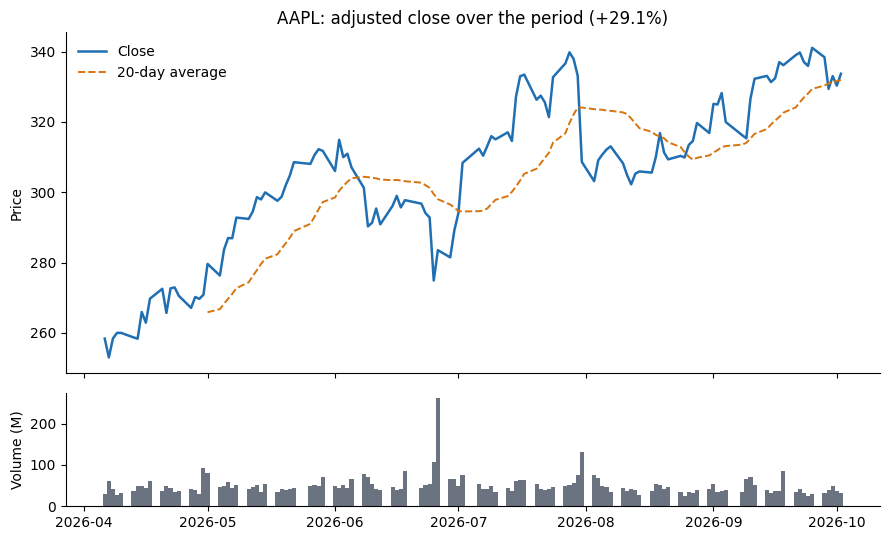

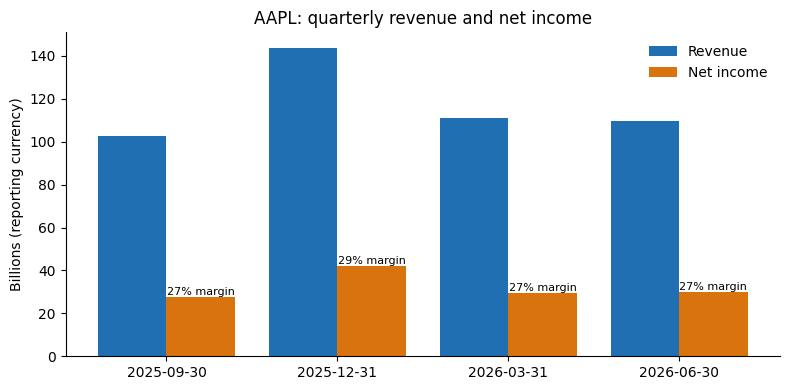

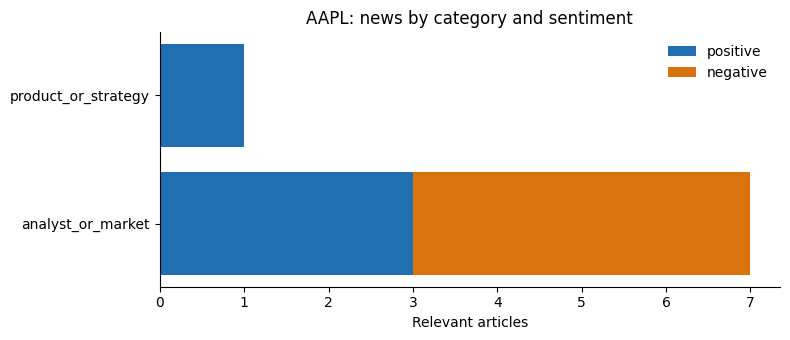

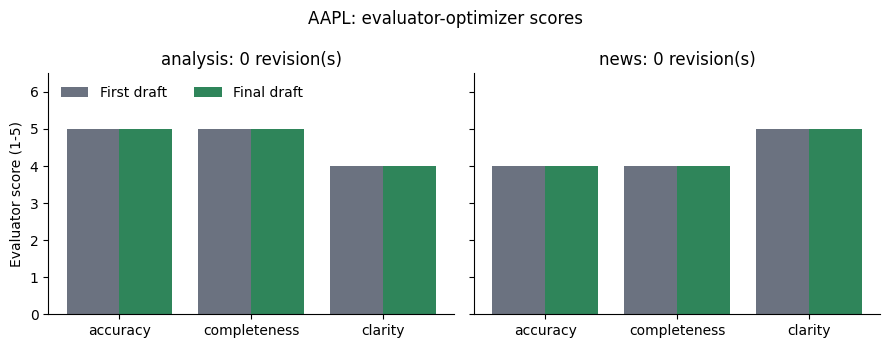

,from,to,task,status
0,Coordinator,Researcher,How has the stock performed over the last six ...,success
1,Researcher,Coordinator,How has the stock performed over the last six ...,success
2,Coordinator,NewsResearcher,How has the stock performed over the last six ...,success
3,NewsResearcher,Coordinator,How has the stock performed over the last six ...,success
4,Coordinator,Evaluator,How has the stock performed over the last six ...,success
5,Coordinator,Evaluator,How has the stock performed over the last six ...,success


In [ ]:
# Run 1: a combined question, so the coordinator should route to both
# specialists and the evaluator-optimizer loop reviews both drafts.
RESET_MEMORY = True  # start the demonstration from an empty memory file
system = InvestmentResearchTeam(client)
if RESET_MEMORY:
    system.memory.clear()

run_1 = system.analyze_stock(
    "AAPL",
    "How has the stock performed over the last six months, how have "
    "revenue and net income changed across reported quarters, and what "
    "recent news might explain it?",
    price_period="6mo",
)
show_run(run_1)

**Interpretation:** The AAPL run completed the full workflow successfully and was routed to both the market and news specialists. Both drafts were approved on the first review. The market analysis received a mean score of 4.67, while the news summary received 4.33. Although neither draft required revision, the evaluator still provided feedback on wording, evidence coverage, and clarity. Because the first-draft scores were below 5.00, this feedback was also available to be generalized into reusable lessons for later runs.

## 10.3 Run 2: MSFT, Using the Lessons from Run 1

The recalled lessons printed below were learned during run 1 and are injected
into the authors' prompts.

Pausing 60 seconds for rate limits...
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'MSFT', 'period': '3mo'}) → success
Researcher: get_company_financials({'ticker': 'MSFT'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the past three 

# MSFT investment research report

**Question:** How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?

**Specialists:** market_data, news | **Generated:** 2026-10-04

## Executive summary
Over the three‑month period from July 6 2026 to October 2 2026, MSFT’s closing price rose from 386.01 to 517.53, an adjusted price change of 34.07%. In the quarter ended June 30 2026 revenue was $90,007,000,000 (up 8.59% quarter‑over‑quarter) and net income was $35,766,000,000 (up 12.55% quarter‑over‑quarter); the prior quarter (March 31 2026) showed revenue up 1.98% quarter‑over‑quarter and net income down –17.37% quarter‑over‑quarter, while the December 31 2025 quarter posted revenue up 4.63% quarter‑over‑quarter and net income up 38.6% quarter‑over‑quarter (the September 30 2025 quarter lacked quarter‑over‑quarter changes). Recent news from late September to early October 2026 was largely positive, highlighting Microsoft’s best quarter since 1998 on Azure and AI growth, analyst upgrades such as a Wells Fargo tactical idea with 41% upside potential and a Redburn price target of $440, a “Humanist AI” code of conduct, and Copilot evolving into an AI operating system, with no negative sentiment detected. Because the news summary is limited to recent Yahoo Finance headlines, it does not incorporate the quarterly revenue or net‑income figures discussed above.

## Market performance and fundamentals
Over the three‑month period from July 6 2026 to October 2 2026, MSFT’s closing price rose from 386.01 to 517.53, an adjusted price change of 34.07%.  
During that span the stock reached a high close of 517.53 and a low close of 380.86, with a maximum drawdown of -5.15% and an average daily volume of 28,246,107 shares; daily volatility averaged 2.48%, translating to an annualized volatility of 39.4%.  
In the quarter ended June 30 2026, revenue was $90,007,000,000 (up 8.59% quarter‑over‑quarter) and net income was $35,766,000,000 (up 12.55% quarter‑over‑quarter).  
For the quarter ended March 31 2026, revenue totaled $82,886,000,000 (up 1.98% quarter‑over‑quarter) and net income totaled $31,778,000,000 (changed -17.37% quarter‑over‑quarter).  
The quarter ended December 31 2025 showed revenue of $81,273,000,000 (up 4.63% quarter‑over‑quarter) and net income of $38,458,000,000 (up 38.6% quarter‑over‑quarter).  
The quarter ended September 30 2025 reported revenue of $77,673,000,000 and net income of $27,747,000,000, with quarter‑over‑quarter changes not available.

| Price metric | Value |
| --- | --- |
| Period | 2026-07-06 to 2026-10-02 |
| Adjusted price change | +34.07% |
| Closing range | 380.86 - 517.53 |
| Maximum drawdown | -5.15% |
| Annualised volatility | 39.40% |

| Quarter end | Revenue | Net income | Net margin | Revenue QoQ | Net income QoQ |
| --- | --- | --- | --- | --- | --- |
| 2026-06-30 | 90.01B | 35.77B | 39.74% | +8.59% | +12.55% |
| 2026-03-31 | 82.89B | 31.78B | 38.34% | +1.98% | -17.37% |
| 2025-12-31 | 81.27B | 38.46B | 47.32% | +4.63% | +38.60% |
| 2025-09-30 | 77.67B | 27.75B | 35.72% | n/a | n/a |

Amounts are in the reporting currency (billions).

## Recent news
Over the period covered by the headlines (late September to early October 2026), Microsoft’s stock received mostly positive coverage, highlighted by reports of its best quarter since 1998 driven by Azure growth and AI optimism (A1) and analyst upgrades such as a Wells Fargo tactical idea with 41% upside potential (A2) and a Redburn price target of $440 (A7). Additional supportive news included the unveiling of a “Humanist AI” code of conduct coinciding with a 2% intraday gain (A8) and Oppenheimer’s view of Copilot evolving into an AI operating system (A4), while neutral pieces noted the stock’s 75% five‑year gain (A6) and a modest Xbox workforce reduction of 268 roles deemed non‑alarmist (A5). The overall sentiment balance leans positive (five positive vs. three neutral articles), with no negative sentiment detected in the sample. Because the analysis is restricted to these recent Yahoo Finance headlines, it does not incorporate quarterly revenue or net‑income figures, which remain outside the scope of this summary.

| Date | Headline | Category | Sentiment |
| --- | --- | --- | --- |
| 2026-10-02 | MSFT Stock Posts Best Quarter Since 1998 As Azure Growth Revives AI Optimism | product_or_strategy | positive |
| 2026-10-01 | MSFT Stock Lands On Wells Fargo’s Q4 ‘Tactical Ideas List’ – Analyst Sees A 41% Upside Potential | analyst_or_market | positive |
| 2026-09-29 | Has MSFT Stock Run Out Of Steam? | analyst_or_market | neutral |
| 2026-09-26 | Microsoft Copilot Is Turning Into An ‘AI Operating System’ — Here’s What It Means For MSFT Stock, According To Oppenheimer’s Brian Schwartz | product_or_strategy | positive |
| 2026-09-23 | Microsoft Is Cutting 268 Xbox Roles as Activision Takes Over Halo. This Is a Simple Restructuring, Not a Broader Panic Signal for MSFT Stock. | other | neutral |
| 2026-09-21 | Microsoft (MSFT) Stock Looks Reasonable Despite Its 75% Five Year Run | analyst_or_market | neutral |
| 2026-09-21 | MSFT Stock: Redburn Raises Target To $440 As AI Safety, Spending Debate Continues | analyst_or_market | positive |
| 2026-09-14 | MSFT Stock Gains 2% — Microsoft Unveils ‘Humanist AI’ Code Of Conduct To Curb Autonomous AI Risks | product_or_strategy | positive |

## Quality review (evaluator-optimizer)
| Draft | Round | accuracy | completeness | clarity | Mean | Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| analysis | 0 | 5 | 3 | 5 | 4.33 | revise |
| analysis | 1 | 5 | 5 | 5 | 5.0 | approve |
| news | 0 | 5 | 5 | 5 | 5.0 | approve |

## Limitations
- Data: Yahoo Finance via yfinance (adjusted daily prices, up to four quarterly income statements, recent headlines); values are not independently verified.
- Four quarters allow quarter-over-quarter comparison only, and seasonality affects it.
- News is limited to the headlines Yahoo returned; category and sentiment labels are model judgements.
- Written by free language models and reviewed by another; this is research support, not investment advice.

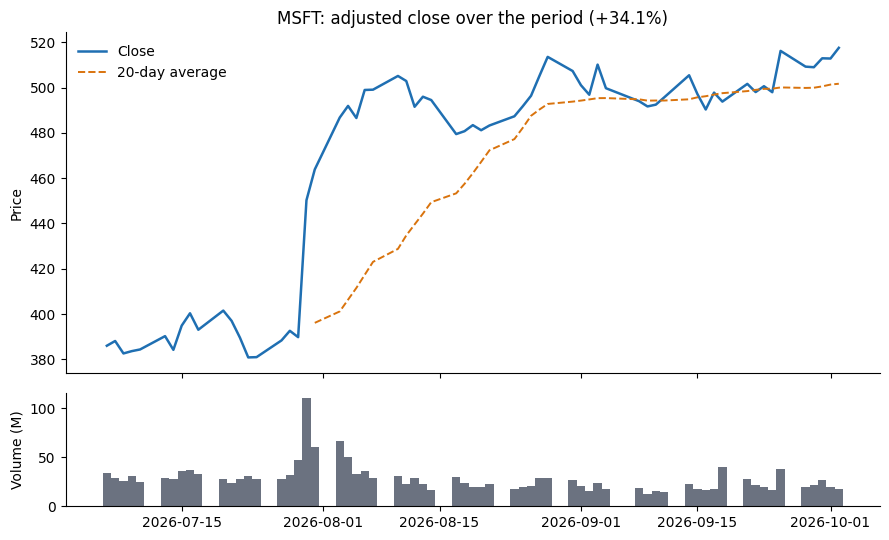

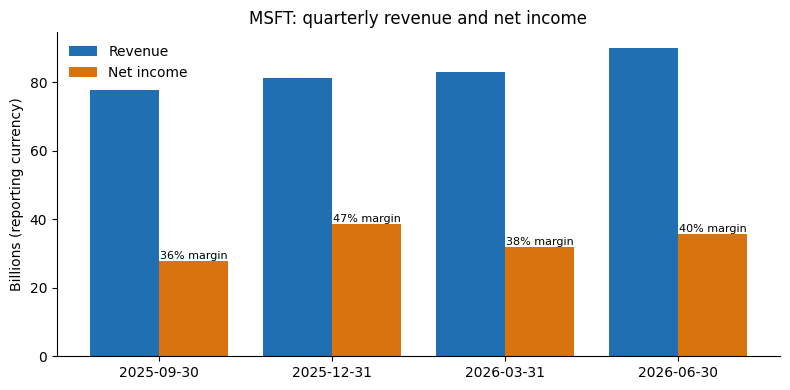

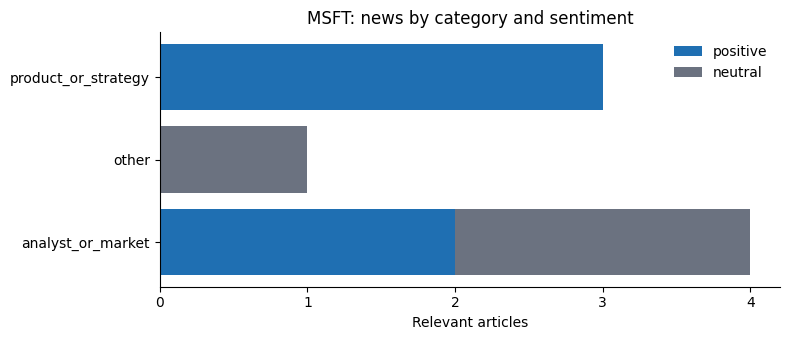

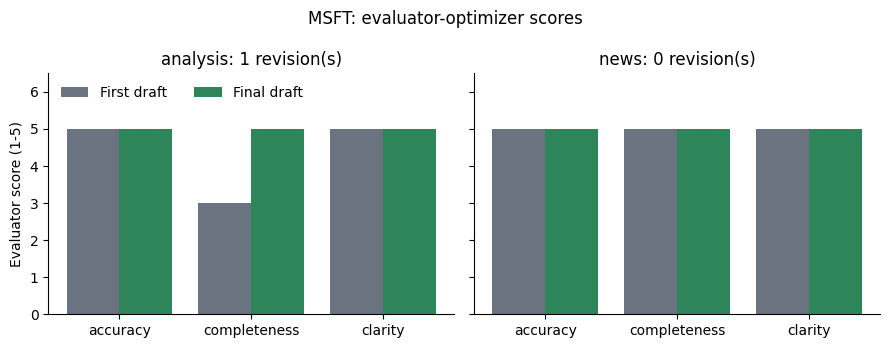

,from,to,task,status
0,Coordinator,Researcher,How has the stock performed over the past thre...,success
1,Researcher,Coordinator,How has the stock performed over the past thre...,success
2,Coordinator,NewsResearcher,How has the stock performed over the past thre...,success
3,NewsResearcher,Coordinator,How has the stock performed over the past thre...,success
4,Coordinator,Evaluator,How has the stock performed over the past thre...,success
5,Coordinator,Researcher,revise analysis,success
6,Coordinator,Evaluator,How has the stock performed over the past thre...,success
7,Coordinator,Evaluator,How has the stock performed over the past thre...,success


In [ ]:
# Pause so the free tier's per-minute rate limit can clear after run 1
print("Pausing 60 seconds for rate limits...")
time.sleep(60)

# Run 2: A different company
# Lessons learned in run 1 are recalled and injected into
# the authors' prompts before they write
run_2 = system.analyze_stock(
    "MSFT",
    "How has the stock performed over the past three months, how have "
    "revenue and net income changed across reported quarters, and what "
    "recent news might explain it?",
    price_period="3mo",
)
print("Lessons recalled for run 2:")
for kind, lessons in run_2["lessons_used"].items():
    print(f"  {kind}: {lessons or 'none yet'}")
show_run(run_2)

**Interpretation:** The MSFT run completed successfully and recalled lessons stored from the AAPL run before generating its drafts. The news summary was approved on the first review, but the market analysis was revised after the evaluator identified a missing quarter and incomplete reporting of the quarterly financial results. The revised analysis received perfect scores, increasing its mean evaluation from 4.33 to 5.00.

## 10.4 Inside the Evaluator-Optimizer loop

The evaluator's feedback, and the first versus revised drafts where a revision happened, for runs 1 and 2. This cell makes no API calls; it only reads the runs already in memory.

In [ ]:
import textwrap


def show_evaluation(packet):
    """Print each evaluator round, its feedback, and what was revised."""

    # Show evaluation results separately for market analysis and news
    for kind, result in packet.get("evaluation", {}).items():
        print(
            f"\n=== {packet['ticker']} {kind}: {result['revisions']} "
            f"revision(s), final verdict: {result['final_verdict']}"
        )

        # Display scores, verdict, and feedback from each evaluator round
        for review in result["rounds"]:
            if "scores" not in review:
                print(f"  round {review['round']}: {review['verdict']}")
                continue

            print(
                f"  round {review['round']}: {review['scores']} -> "
                f"{review['verdict']}"
            )
            print(
                textwrap.fill(
                    "feedback: " + review["feedback"],
                    100,
                    initial_indent="    ",
                    subsequent_indent="    ",
                )
            )

        # If a revision occurred, compare the first and final drafts
        data = packet["analysis"] if kind == "analysis" else packet["news"]
        history = data.get("revision_history", [])

        if history:
            final = (
                data["narrative"] if kind == "analysis" else data["summary"]
            )

            for title, text in (
                ("FIRST DRAFT", history[0]["draft"]),
                ("REVISED DRAFT", final),
            ):
                print(f"\n  {title}:")
                print(
                    textwrap.fill(
                        text,
                        100,
                        initial_indent="  ",
                        subsequent_indent="  ",
                    )
                )


# Inspect the evaluator-optimizer results from runs 1 and 2; no API calls
for packet in (run_1, run_2):
    show_evaluation(packet)


=== AAPL analysis: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 5, 'completeness': 5, 'clarity': 4} -> approve
    feedback: Replace the double-negative phrasing "revenue fell –1.59%" and "revenue dropped
    –22.66%" with "revenue declined 1.59%" and "revenue declined 22.66%" for cleaner prose.

=== AAPL news: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 4, 'completeness': 4, 'clarity': 5} -> approve
    feedback: Remove or support the unsupported 'Yahoo Finance' source attribution. State clearly
    that the available evidence covers only late September to early October 2026, not a full six-
    month price history. Also connect the news themes more explicitly to the stock movement: recent
    strength from the 10% monthly gain and record highs, offset by valuation/execution concerns from
    the modest 6M iPhone Duo forecast, AI-cost warnings, potential 32% overvaluation, Fitness+
    layoffs, and new wearable/AI-server reports.

=== MSFT analysis:

**Interpretation:** Looking across the first two runs makes the evaluator-optimizer behavior more visible. The evaluator approved both AAPL drafts and the MSFT news summary on their first reviews, even when it provided suggestions for improvement. It required a revision only for the MSFT market analysis, where it identified a substantive completeness issue. This shows that the review step acts as a quality gate rather than automatically rewriting every response.

## 10.5 Run 3: Using Accumulated Lessons

Runs 1 and 2 can leave reusable lessons in persistent memory. Run 3 starts with the
lessons accumulated from those earlier runs and demonstrates that stored feedback is recalled and injected into later author prompts. In this executed example,
Run 3 recalls both analysis and news guidance before generating its drafts.

Pausing 60 seconds for rate limits...
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Coordinator: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Coordinator → Researcher: How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher: get_stock_prices({'ticker': 'NVDA', 'period': '3mo'}) → success
Researcher: get_company_financials({'ticker': 'NVDA'}) → success
Researcher: attempt 1/3 — nvidia/nemotron-3-super-120b-a12b:free
Researcher: accepted response from nvidia/nemotron-3-super-120b-a12b:free
Researcher → Coordinator: How has the stock performed over the past three 

# NVDA investment research report

**Question:** How has the stock performed over the past three months, how have revenue and net income changed across reported quarters, and what recent news might explain it?

**Specialists:** market_data, news | **Generated:** 2026-10-04

## Executive summary
Over the three‑month period from July 6 2026 to October 2 2026, NVDA’s price rose from a close of 195.33 to 233.95, an adjusted price change of 19.77% with a maximum drawdown of ‑10.58%. Quarter‑over‑quarter changes showed revenue growth of 19.51% and net‑income growth of 34.63% for the quarter ended January 31 2026; revenue up 19.8% and net income up 35.76% for the quarter ended April 30 2026; and revenue up 17.9% with net income up 2.34% for the quarter ended July 31 2026. Recent headlines from late September to early October 2026 note the stock hitting a record high and eyeing a third straight monthly gain, cite Morgan Stanley naming Nvidia a top pick, reference a 106% revenue growth headline, highlight a record share‑buyback increase, a new data‑center digital‑twin deal, and reports that China may allow ByteDance and Alibaba to purchase some Nvidia AI chips. The news summary covers only late September‑early October headlines and does not constitute a full three‑month performance review or include complete quarterly revenue or net‑income data.

## Market performance and fundamentals
Over the three‑month period from July 6 2026 to October 2 2026, NVDA’s price rose from a close of 195.33 to 233.95, an adjusted price change of 19.77%.  
During that span the stock reached a high close of 233.95 and a low close of 189.80, with a maximum drawdown of -10.58% and a daily volatility of 2.42% (annualized 38.46%).  
For the quarter ended July 31 2026, revenue was 96,221,000,000 and net income was 59,688,000,000, giving a net margin of 62.03%, with quarter‑over‑quarter revenue growth of 17.9% and net‑income growth of 2.34%.  
In the quarter ended April 30 2026, revenue totaled 81,615,000,000 and net income was 58,321,000,000 (net margin 71.46%), reflecting QoQ revenue increase of 19.8% and net‑income rise of 35.76%.  
The quarter ended January 31 2026 reported revenue of 68,127,000,000 and net income of 42,960,000,000 (net margin 63.06%), with QoQ revenue up 19.51% and net income up 34.63%; the earliest quarter shown (October 31 2025) had revenue of 57,006,000,000 and net income of 31,910,000,000 (net margin 55.98%) and no QoQ percentages are available.

| Price metric | Value |
| --- | --- |
| Period | 2026-07-06 to 2026-10-02 |
| Adjusted price change | +19.77% |
| Closing range | 189.8 - 233.95 |
| Maximum drawdown | -10.58% |
| Annualised volatility | 38.46% |

| Quarter end | Revenue | Net income | Net margin | Revenue QoQ | Net income QoQ |
| --- | --- | --- | --- | --- | --- |
| 2026-07-31 | 96.22B | 59.69B | 62.03% | +17.90% | +2.34% |
| 2026-04-30 | 81.61B | 58.32B | 71.46% | +19.80% | +35.76% |
| 2026-01-31 | 68.13B | 42.96B | 63.06% | +19.51% | +34.63% |
| 2025-10-31 | 57.01B | 31.91B | 55.98% | n/a | n/a |

Amounts are in the reporting currency (billions).

## Recent news
Recent headlines from late September to early October 2026 show NVDA stock hitting a record high and trading upward, with one article noting it eyes a third straight monthly gain [A1][A3][A4]. The upward price movement coincides with positive analyst commentary—Morgan Stanley naming Nvidia a top pick, a fair‑value boost from shifting analyst views, and intraday trading up [A2][A4]. Fundamental news cited includes a single headline reporting 106% revenue growth, while no net‑income figures appear in the provided headlines [A5]. Additional developments highlighted as positive catalysts are the company’s largest ever share‑buyback increase, a new data‑center digital‑twin deal, and reports that China may allow ByteDance and Alibaba to purchase some Nvidia AI chips [A6][A7][A8]. Coverage is limited to the recent headlines supplied and does not constitute a full three‑month performance review or include complete quarterly revenue or net‑income data.

| Date | Headline | Category | Sentiment |
| --- | --- | --- | --- |
| 2026-10-02 | NVDA Stock Hits Record High After Morgan Stanley Names Nvidia Top Pick, Says AI Trends Play To Its ‘Strengths’ | analyst_or_market | positive |
| 2026-10-01 | Nvidia (NVDA) Stock Gets Fair Value Boost As AI Demand And Analyst Views Shift | analyst_or_market | positive |
| 2026-09-30 | NVDA Stock Eyes Third Straight Monthly Gain: Nvidia Adds Data Center Digital Twin Deal | product_or_strategy | positive |
| 2026-09-28 | Why Nvidia (NVDA) Stock Is Trading Up Today | analyst_or_market | positive |
| 2026-09-28 | Nvidia Just Delivered 106% Revenue Growth. What Could NVDA Stock Do Next? | earnings | positive |
| 2026-09-28 | NVDA Stock Climbs After Nvidia Approves ‘Largest Buyback Increase’ In Company History | product_or_strategy | positive |
| 2026-09-28 | NVDA Stock In Focus: China Reportedly Weighs Letting ByteDance, Alibaba Buy Some Nvidia AI Chips | regulatory_or_legal | positive |
| 2026-09-27 | China May Reopen Nvidia's AI Market. How Will NVDA Stock React Monday? | regulatory_or_legal | positive |

## Quality review (evaluator-optimizer)
| Draft | Round | accuracy | completeness | clarity | Mean | Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| analysis | 0 | 5 | 5 | 5 | 5.0 | approve |
| news | 0 | 2 | 4 | 3 | 3.0 | revise |
| news | 1 | 5 | 5 | 5 | 5.0 | approve |

## Limitations
- Data: Yahoo Finance via yfinance (adjusted daily prices, up to four quarterly income statements, recent headlines); values are not independently verified.
- Four quarters allow quarter-over-quarter comparison only, and seasonality affects it.
- News is limited to the headlines Yahoo returned; category and sentiment labels are model judgements.
- Written by free language models and reviewed by another; this is research support, not investment advice.

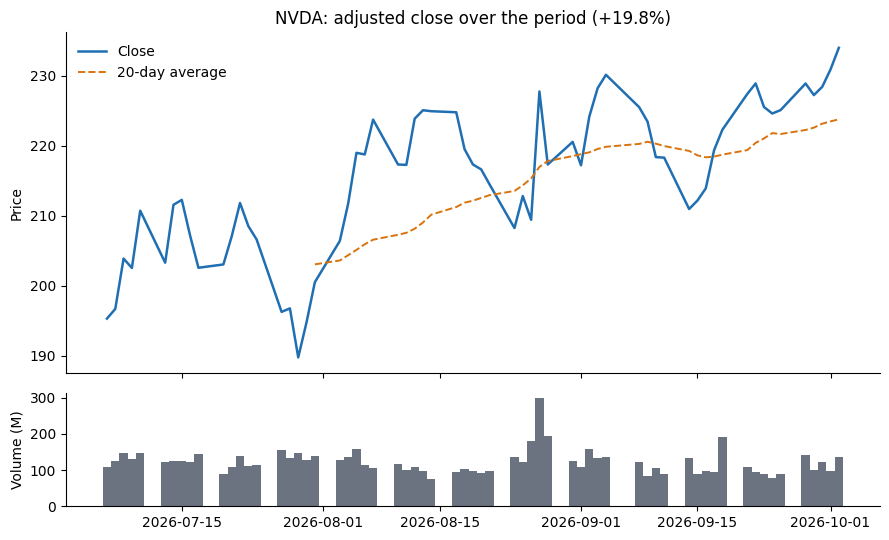

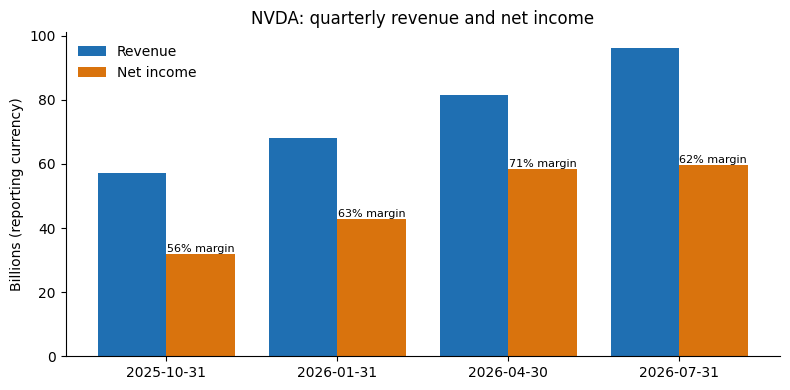

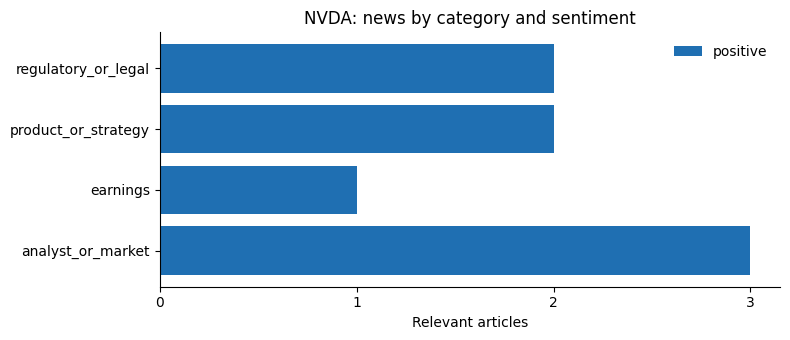

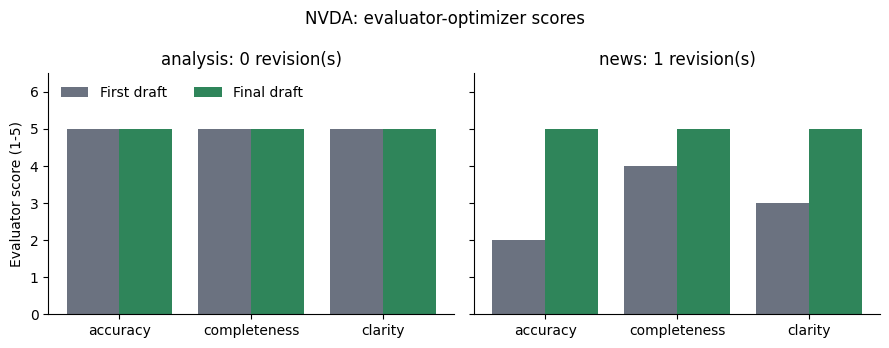

,from,to,task,status
0,Coordinator,Researcher,How has the stock performed over the past thre...,success
1,Researcher,Coordinator,How has the stock performed over the past thre...,success
2,Coordinator,NewsResearcher,How has the stock performed over the past thre...,success
3,NewsResearcher,Coordinator,How has the stock performed over the past thre...,success
4,Coordinator,Evaluator,How has the stock performed over the past thre...,success
5,Coordinator,Evaluator,How has the stock performed over the past thre...,success
6,Coordinator,NewsResearcher,revise news,success
7,Coordinator,Evaluator,How has the stock performed over the past thre...,success



=== NVDA analysis: 0 revision(s), final verdict: approve
  round 0: {'accuracy': 5, 'completeness': 5, 'clarity': 5} -> approve
    feedback: No changes needed.

=== NVDA news: 1 revision(s), final verdict: approve
  round 0: {'accuracy': 2, 'completeness': 4, 'clarity': 3} -> revise
    feedback: Replace the impossible 'three-month window from late September to early October 2026'
    with 'recent headlines from late September to early October 2026' and state that the evidence
    does not cover a full three-month period. Do not say NVDA 'posted' or 'multiple straight monthly
    gains'; A3 says it 'eyes' a third straight monthly gain. Remove 'Yahoo Finance' and the causal
    'contributed' language, and say the buyback, digital-twin deal, and China reports were reported
    as positive catalysts. Clarify that the evidence contains only one 106% revenue-growth headline
    and no quarter-by-quarter revenue or net-income data.
  round 1: {'accuracy': 5, 'completeness': 5, 'clarity': 5

In [ ]:
# Run 3: A third company
# The lesson stored after run 2 is now recalled and given to
# the authors before they write
print("Pausing 60 seconds for rate limits...")
time.sleep(60)

run_3 = system.analyze_stock(
    "NVDA",
    "How has the stock performed over the past three months, how have "
    "revenue and net income changed across reported quarters, and what "
    "recent news might explain it?",
    price_period="3mo",
)
print("Lessons recalled for run 3:")
for kind, lessons in run_3["lessons_used"].items():
    print(f"  {kind}: {lessons or 'none yet'}")
show_run(run_3)
show_evaluation(run_3)

**Interpretation:** The NVDA run shows the system using feedback accumulated from the earlier runs. It recalled two analysis lessons and one news lesson before generating the new drafts. The market analysis was approved on the first review with a mean score of 5.00. The news summary required one revision after the evaluator identified inaccurate time-frame language, overstatement of tentative headline claims, and overly causal wording. After revision, the news score improved from 3.00 to 5.00. Although this single run cannot show that memory caused the results, it confirms that stored lessons were successfully retrieved and incorporated into a later run.

## 10.6 What the System Remembers

This section summarizes what the system retained across runs, including evaluator scores, revisions, and the lessons recalled by later runs. It also prints the stored lessons so we can see how feedback from earlier drafts is carried forward.

In [ ]:
# What the system remembers: scores per run and the stored lessons
history = system.memory.history()
display(
    history[[
        "ticker",
        "kind",
        "first_mean",
        "final_mean",
        "revisions",
        "lessons_used",
    ]]
)
print("\nStored lessons:")
for item in system.memory.data["lessons"]:
    print(f"  [{item['kind']}] {item['lesson']}")
display(system.show_team_status())
print("Handoff file written to:", save_handoff(run_3, "research_run.json"))

,ticker,kind,first_mean,final_mean,revisions,lessons_used
0,AAPL,analysis,4.67,4.67,0,0
1,AAPL,news,4.33,4.33,0,0
2,MSFT,analysis,4.33,5.00,1,1
3,MSFT,news,5.00,5.00,0,1
4,NVDA,analysis,5.00,5.00,0,2
5,NVDA,news,3.00,5.00,1,1



Stored lessons:
  [analysis] Use positive verb forms with negative numbers; avoid double‑negative constructions.
  [news] Cite all sources, clarify the period covered by evidence, and directly connect each discussed theme to the observed price movement.
  [analysis] Ensure all reported fiscal periods are fully disclosed with revenue and net income figures, and refrain from adding speculative commentary.
  [news] Specify time frames accurately, qualify evidence limits, avoid causal language, and describe catalysts as reported without implying unverified gains.


,agent,completed_tasks_this_session
0,Coordinator,6
1,Researcher,3
2,NewsResearcher,3
3,Evaluator,8


Handoff file written to: /content/research_run.json


**Interpretation:** The final memory history summarizes how evaluation and learning changed across the three runs. Two of the six drafts required revisions: the MSFT market analysis improved from a mean score of 4.33 to 5.00, and the NVDA news summary improved from 3.00 to 5.00. Four general lessons were stored over the course of the demonstration, with later runs recalling more prior guidance than earlier ones. The output confirms that evaluator feedback is being preserved and reused across runs rather than disappearing after each individual analysis.

## 10.7 Rubric Verification and Agent-Delegation Evidence

The table below links each graded requirement to executed evidence in this notebook, so the required agentic behavior is directly visible rather than inferred from class definitions alone.

| Graded requirement | Evidence Demonstrated in the Notebook |
| --- | --- |
| **Plans research steps** | Section 4 prints the Coordinator's numbered plan before retrieval. |
| **Uses tools dynamically** | Section 4 shows LLM-selected Yahoo Finance calls; the MSFT price-only test prints `PASS` only when the correct tool and `3mo` period are selected while financials are excluded. |
| **Self-reflects** | Sections 7 and 10.4 show the independent Evaluator scoring drafts against the available evidence and returning specific feedback. |
| **Learns across runs** | Sections 8 and 10.6 show persistent lessons in `agent_memory.json`, the number of lessons recalled, and first/final evaluator scores across AAPL, MSFT, and NVDA. |
| **Prompt chaining** | Section 5 displays the full `ingest -> preprocess -> classify -> extract -> summarize` trace, including the relevance gate. |
| **Routing** | Section 6 demonstrates market-only, news-only, and combined requests being routed to different specialists. |
| **Evaluator-optimizer** | Sections 10.4-10.6 show evaluator rounds with revision and re-evaluation. The MSFT market analysis improves from a mean evaluator score of 4.33 to 5.00 after one revision, and the NVDA news summary improves from 3.00 to 5.00 after one revision. |
| **Agent-to-agent delegation** | End-to-end delegation logs show `Coordinator -> Researcher -> Coordinator`, `Coordinator -> NewsResearcher -> Coordinator`, and `Coordinator -> Evaluator`. The MSFT log includes `Coordinator -> Researcher` for `revise analysis`, while the NVDA log includes `Coordinator -> NewsResearcher` for `revise news`. |
| **Code quality / robustness** | Section 10.1 reports that all offline tests pass; schemas, bounded retries, explicit error states, and deterministic metric calculations are documented throughout. |
| **Visual communication** | Section 9 produces price/volume, quarterly fundamentals, news sentiment/category, and evaluator-score visualizations from the evidence packet. |
| **GitHub** | The repository link is included at the top of the notebook and the repository contains the required README. |

These outputs demonstrate all four required agent functions and all three required workflow patterns. RAG is not included because it is optional and does not add value to the direct live data retrieval used for this project.

---
# 11. Conclusions, Limitations, and Future Improvements

## Conclusions

The end-to-end runs show that the system can complete the intended research workflow across multiple companies. AAPL, MSFT, and NVDA all finished successfully, were routed by the LLM to both the market and news specialists, and produced a final research report with supporting charts. The delegation logs also show the Coordinator assigning work to the Researcher and NewsResearcher, receiving their results, and sending drafts to the Evaluator for review.

The evaluator changed two of the six drafts. The MSFT market analysis improved from a mean score of 4.33 to 5.00 after the evaluator identified incomplete reporting of the quarterly financial results. The NVDA news summary improved from 3.00 to 5.00 after the evaluator identified inaccurate time-frame language, overstatement of tentative headline claims, and overly causal wording. The other four drafts were approved on their first review. These examples show that the evaluator can identify specific problems and use its feedback to produce a stronger revised draft rather than simply assigning a score.

The memory component also carried feedback across runs. By the end of the demonstration, four general lessons had been stored. Run 2 recalled one analysis lesson and one news lesson from the first run, while Run 3 recalled two analysis lessons and one news lesson accumulated from the earlier runs. The three runs are not enough to determine whether memory consistently improves draft quality, but they do show that evaluator feedback can be converted into reusable guidance and applied to later analyses.

The runs also illustrate some of the practical challenges of relying on free LLMs. Temporary rate limits occurred during evaluation, and the system successfully moved to a fallback model when this happened. All three end-to-end runs used the LLM router successfully, so the rule-based routing fallback was not needed in these examples.

## Limitations

The system has several limitations worth noting. Financial data is retrieved from Yahoo Finance through yfinance and is not independently verified. The analysis also relies on a relatively small number of quarterly financial statements, which limits longer term comparisons. News coverage is restricted to the titles and summaries returned by Yahoo Finance rather than full article text. Relevance, category, sentiment, extracted facts, and the final news summary are generated by language models. Although prompts restrict these stages to the retrieved source material and structured outputs are schema-validated, the extracted facts and summary are not independently verified against the original Yahoo Finance text.

The evaluation process has similar constraints. The Evaluator is itself an LLM, and although the deterministic grounding check can catch unsupported percentages, it cannot verify every factual statement or determine whether all financial reasoning is sound. The end-to-end demonstration also includes only three companies, so it shows that the workflow and memory mechanisms function as intended but does not establish that stored lessons consistently improve later results. The current memory system stores short rules in a JSON file and recalls them primarily by recency rather than by their relevance to a new question. Finally, the system is designed to support research and summarize available evidence rather than predict stock prices or provide investment advice.

## Future Improvements

Future work could expand both the available evidence and the evaluation process. The system could incorporate SEC filings, earnings transcripts, analyst estimates, and macroeconomic data to provide a broader basis for each analysis. Retrieval-augmented generation could also be added for longer documents so the agents can retrieve relevant passages rather than relying only on short API responses.

The evaluation and memory components could also be strengthened. A stronger evaluator model or human ratings could be used to compare against the automated review scores, and the effect of memory could be tested across a larger number of companies and repeated runs. The current memory system could also be improved by retrieving lessons based on their relevance to the current task rather than only their recency. Additional improvements could include parallelizing specialist tasks, caching repeated data requests, and adding a human review step before final reports are used for higher stakes financial decisions.

---
# 12. References

Anthropic. (2024). *Building effective agents*.
https://www.anthropic.com/engineering/building-effective-agents

Aroussi, R. (n.d.). *yfinance* [Computer software]. GitHub.
https://github.com/ranaroussi/yfinance

Berman, J. (n.d.). *jsonschema* [Computer software].
https://python-jsonschema.readthedocs.io/

Madaan, A., Tandon, N., Gupta, P., Hallinan, S., Gao, L., Wiegreffe, S.,
Alon, U., Dziri, N., Prabhumoye, S., Yang, Y., Gupta, S., Majumder, B. P.,
Hermann, K., Welleck, S., Yazdanbakhsh, A., & Clark, P. (2023).
Self-Refine: Iterative refinement with self-feedback. *Advances in Neural
Information Processing Systems, 36*.
https://doi.org/10.52202/075280-2019

OpenRouter. (n.d.). *OpenRouter documentation*.
https://openrouter.ai/docs

Shinn, N., Cassano, F., Gopinath, A., Narasimhan, K., & Yao, S. (2023).
Reflexion: Language agents with verbal reinforcement learning. *Advances in
Neural Information Processing Systems, 36*.
https://doi.org/10.52202/075280-0377

University of San Diego. (2026). *Agentic AI* [Course presentation].
Natural Language Processing and GenAI (AAI-520), Applied Artificial
Intelligence program.

University of San Diego. (2026). *Lab 7* [Course lab]. Natural Language
Processing and GenAI (AAI-520), Applied Artificial Intelligence program.

van Rossum, G., Warsaw, B., & Coghlan, A. (2001). *PEP 8 – Style guide for
Python code*. Python Software Foundation.
https://peps.python.org/pep-0008/

Wright, A., Andrews, H., Hutton, B., & Dennis, G. (2022). *JSON Schema: A
media type for describing JSON documents* (Draft 2020-12). JSON Schema.
https://json-schema.org/draft/2020-12/json-schema-core.html

Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K., & Cao, Y.
(2023). ReAct: Synergizing reasoning and acting in language models.
*International Conference on Learning Representations*.
https://openreview.net/forum?id=WE_vluYUL-X

---
# 13. Generative AI Use Statement

OpenAI ChatGPT (GPT-5.6 Sol) was used as a development aid to review code and notebook organization, identify potential inconsistencies between the documentation and implementation, and suggest revisions for clarity and rubric alignment. All suggestions were reviewed and modified by the team, and the team is responsible for the final code, analyses, interpretations, and written content. The LLMs accessed through OpenRouter are part of the implemented multi-agent system and are documented throughout the notebook.